# Clean Centralized Bubble Analysis

## Abstract

This notebook provides a clean and centralized workflow for the bubble problem at finite density. We analyze the effective potential and grand potential, identify false/true vacua of $\Omega(\phi)$, compute one-dimensional bounce solutions for different $O(d)$ symmetries, study charge/energy observables, perform scans in $\omega$, and then solve the full two-dimensional Euclidean problem with a unified seed framework.

The notebook is designed as the new main analysis notebook: concise, reproducible, and reusable, with implementation details moved to Python modules whenever possible.

## Table of Contents

- [1. Project Setup, Imports, and Global Configuration](#1-project-setup-imports-and-global-configuration)
- [2. Potential and Vacua of $\Omega$](#2-potential-and-vacua-of-omega)
- [3. One-Dimensional Bounce Solutions at Fixed $\omega$](#3-one-dimensional-bounce-solutions-at-fixed-omega)
- [4. One-Dimensional Charge, Energy, and Density Diagnostics](#4-one-dimensional-charge-energy-and-density-diagnostics)
- [5. One-Dimensional Scan in $\omega$](#5-one-dimensional-scan-in-omega)
- [6. Two-Dimensional Problem: Conventions and Solver Logic](#6-two-dimensional-problem-conventions-and-solver-logic)
- [7. Default 2D Grid and Solver Parameters](#7-default-2d-grid-and-solver-parameters)
- [8. Unified 2D Seed System](#8-unified-2d-seed-system)
- [9. Focus Study: O(4)-Inspired Seed](#9-focus-study-o4-inspired-seed)
- [10. 2D Newton Solve from O(4) Seed and $\eta_0$ Scan](#10-2d-newton-solve-from-o4-seed-and-eta_0-scan)
- [11. Final O(4)-Based 2D Solution and 1D Comparisons](#11-final-o4-based-2d-solution-and-1d-comparisons)
- [12. Energy Decomposition in Terms of $\rho_{\mathrm{phys}}$ and $\beta$](#12-energy-decomposition-in-terms-of-rho_mathrmphys-and-beta)
- [13. Parallel 2D Analyses for O(3), O(1), and Homogeneous Seeds](#13-parallel-2d-analyses-for-o3-o1-and-homogeneous-seeds)
- [14. Descending Beta Continuation Scan for O(4), O(3), and O(1) Seeds](#14-descending-beta-continuation-scan-for-o4-o3-and-o1-seeds)
- [15. O(4) Branch Omega Scan with Eta Matching](#15-o4-branch-omega-scan-with-eta-matching)
- [16. Fancy Plots: Symmetry-Extended O(4) Map](#16-fancy-plots-symmetry-extended-o4-map)
- [17. Final Sanity Check and Cleanup Candidates](#17-final-sanity-check-and-cleanup-candidates)


## 1. Project Setup, Imports, and Global Configuration

We first set paths robustly, import all required backend modules once, and define global plotting/runtime configuration. The rest of the notebook reuses these objects and avoids repeated imports or duplicated setup cells.

The plotting style is configured globally with LaTeX-like serif/math fonts, consistent labels, and publication-ready defaults.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Robust project-root discovery (works if notebook is run from different cwd values)
def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "BubbleX" / "Bubble_finder").exists():
            return parent
    raise RuntimeError("Could not locate repository root containing BubbleX/Bubble_finder")

PROJECT_ROOT = find_repo_root(Path.cwd())
BUBBLEX_ROOT = PROJECT_ROOT / "BubbleX"
NOTEBOOK_DIR = BUBBLEX_ROOT / "Bubble_finder" / "notebooks"

if str(BUBBLEX_ROOT) not in sys.path:
    sys.path.insert(0, str(BUBBLEX_ROOT))

from Bubble_finder.potential_bubble import V_phi, dV_dphi, d2V_dphi2, Omega_phi, vacua_of_Omega, dOmega_dphi
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V
from Bubble_finder.observables_1d import (
    compute_charge,
    compute_energy_minkowski_1d_spherical,
    compute_free_energy_grandcanonical,
)
from Bubble_finder.observables_2d import (
    compute_observables_tau0_ghost,
    compute_targets_tau0_ghost,
    compute_charge_tau0_ghost_2d,
)
from Bubble_finder.clean_analysis_helpers import (
    ModelParams,
    configure_matplotlib,
    solve_or_load_bounce_1d,
    compute_1d_observables,
    run_1d_scan,
    build_seed,
    run_newton_with_eta_scan,
    summarize_solution,
    compute_static_energy_minus_hom_vs_tau,
    plot_seed_maps,
    plot_solution_maps,
)

# Global runtime/plotting configuration
CFG = {
    "save_figures": False,
    "use_tex": True,
    "random_seed": 7,
    "figures_dir": NOTEBOOK_DIR / "figures_clean",
    "cache_1d_dir": NOTEBOOK_DIR / "cache_1d_clean",
    "cache_scan_dir": NOTEBOOK_DIR / "cache_scan_clean",
}

np.random.seed(CFG["random_seed"])
CFG["figures_dir"].mkdir(parents=True, exist_ok=True)
CFG["cache_1d_dir"].mkdir(parents=True, exist_ok=True)
CFG["cache_scan_dir"].mkdir(parents=True, exist_ok=True)

configure_matplotlib(use_tex=CFG["use_tex"], fontsize=12, dpi=140)

print(f"Project root: {PROJECT_ROOT}")
print(f"BubbleX root:  {BUBBLEX_ROOT}")
print(f"Figures dir:   {CFG['figures_dir']}")
print(f"1D cache dir:  {CFG['cache_1d_dir']}")


Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay
BubbleX root:  /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Figures dir:   /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/notebooks/figures_clean
1D cache dir:  /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/notebooks/cache_1d_clean


## 2. Potential and Vacua of $\Omega$

We use the model potential $V(\phi)$ implemented in `potential_bubble.py`, and define the grand potential

$$
\Omega(\phi) = V(\phi) - \frac{1}{2}\,\omega^2\phi^2.
$$

For each fixed $\omega$, the extrema of $\Omega$ determine metastable and stable vacua. We denote by $\phi_{\mathrm{false}}$ the local minimum with higher $\Omega$, and by $\phi_{\mathrm{true}}$ the one with lower $\Omega$.

Because of the $-\tfrac12\omega^2\phi^2$ term, these vacua are $\omega$-dependent.


Reference parameters: phi0=1.999, v1=1.0, v2=2.0, omega=0.95
False vacuum: phi_false = 1.0312018015
True vacuum:  phi_true  = 2.0656590991


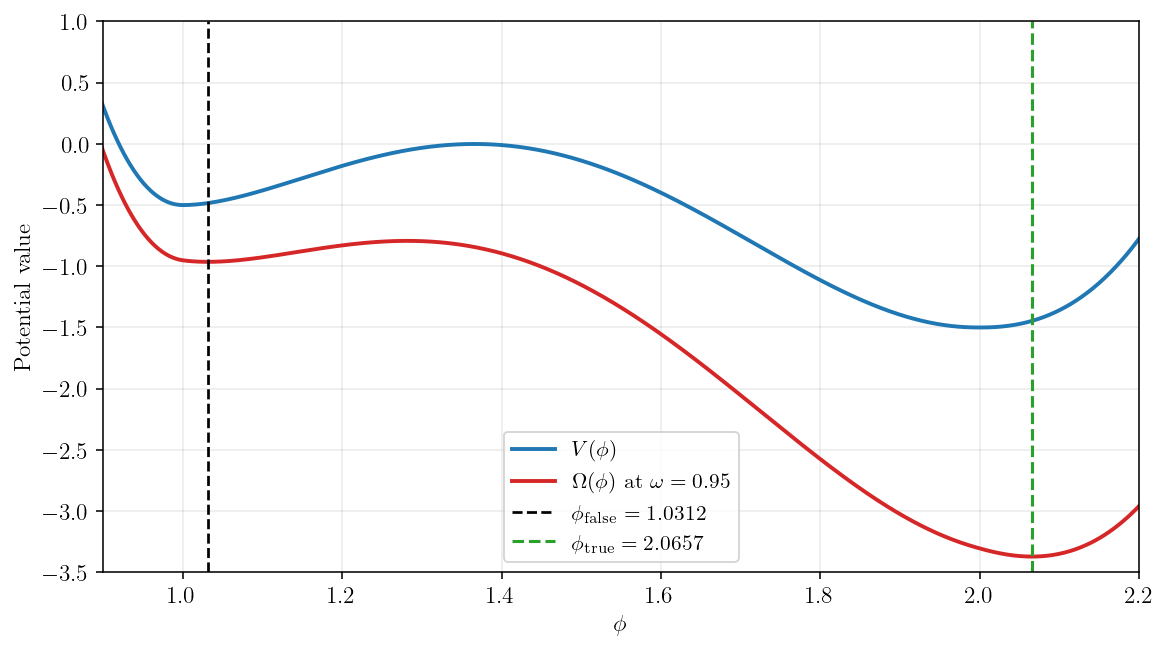

In [72]:
# Model parameters and reference omega
MODEL = ModelParams(phi0=1.999, v1=1.0, v2=2.0)
OMEGA_REF = 0.95

phi_grid = np.linspace(MODEL.v1-0.2, MODEL.v2 + 0.2, 1000)
V_vals = V_phi(phi_grid, MODEL.phi0, MODEL.v1, MODEL.v2)
Om_vals = Omega_phi(phi_grid, MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF)

phi_false_ref, phi_true_ref = vacua_of_Omega(
    MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF, verbose=False
)

print(f"Reference parameters: phi0={MODEL.phi0}, v1={MODEL.v1}, v2={MODEL.v2}, omega={OMEGA_REF}")
print(f"False vacuum: phi_false = {phi_false_ref:.10f}")
print(f"True vacuum:  phi_true  = {phi_true_ref:.10f}")

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(phi_grid, V_vals, color="C0", label=r"$V(\phi)$")
ax.plot(phi_grid, Om_vals, color="C3", label=rf"$\Omega(\phi)$ at $\omega={OMEGA_REF:.2f}$")

ax.axvline(phi_false_ref, color="k", ls="--", lw=1.4, label=rf"$\phi_{{\mathrm{{false}}}}={phi_false_ref:.4f}$")
ax.axvline(phi_true_ref, color="C2", ls="--", lw=1.6, label=rf"$\phi_{{\mathrm{{true}}}}={phi_true_ref:.4f}$")

ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"Potential value")
ax.set_xlim(MODEL.v1*0.9, MODEL.v2*1.1)
ax.set_ylim(-3.5, 1)
#ax.set_title(r"$V(\phi)$ and $\Omega(\phi)$ on the same axis")
ax.legend(loc="best")

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "potential_and_omega_vacua.pdf", bbox_inches="tight")
plt.show()


## 3. One-Dimensional Bounce Solutions at Fixed $\omega$

For an $O(d)$-symmetric profile $\phi(r)$, the radial equation is

$$
\phi''(r) + \frac{d-1}{r}\phi'(r) = \frac{\partial \Omega}{\partial \phi}.
$$

We compute $d=1,3,4$:

- $d=1$: reference one-dimensional radial equation (useful as a limiting/profile diagnostic),
- $d=3$: finite-density thermal-like bounce sector,
- $d=4$: Euclidean instanton-like sector.

We do this both at a fixed reference $\omega$ and at $\omega=0$. All solutions are cached and reusable.


In [73]:
DIMENSIONS = (1, 3, 4)
OMEGA_SET = {
    "omega_ref": float(OMEGA_REF),
    "omega_zero": 0.0,
}

bounces_fixed: dict[str, dict[int, dict]] = {k: {} for k in OMEGA_SET}

for om_label, om in OMEGA_SET.items():
    for d in DIMENSIONS:
        bounces_fixed[om_label][d] = solve_or_load_bounce_1d(
            CFG["cache_1d_dir"],
            MODEL,
            omega=om,
            d=d,
            rmax=260.0,
            n_grid_points=1000,
            max_iter=180,
            verbose=False,
        )

print("Cached/loaded 1D profiles:")
for om_label, dct in bounces_fixed.items():
    print(f"  {om_label}:")
    for d, b in dct.items():
        src = "cache" if b["from_cache"] else "new"
        print(f"    O({d}): points={len(b['r'])}, phi_false={b['phi_false']:.6f}, source={src}")


Cached/loaded 1D profiles:
  omega_ref:
    O(1): points=1000, phi_false=1.031202, source=new
    O(3): points=1000, phi_false=1.031202, source=new
    O(4): points=1000, phi_false=1.031202, source=new
  omega_zero:
    O(1): points=1000, phi_false=1.000000, source=cache
    O(3): points=1000, phi_false=1.000000, source=cache
    O(4): points=1000, phi_false=1.000000, source=cache


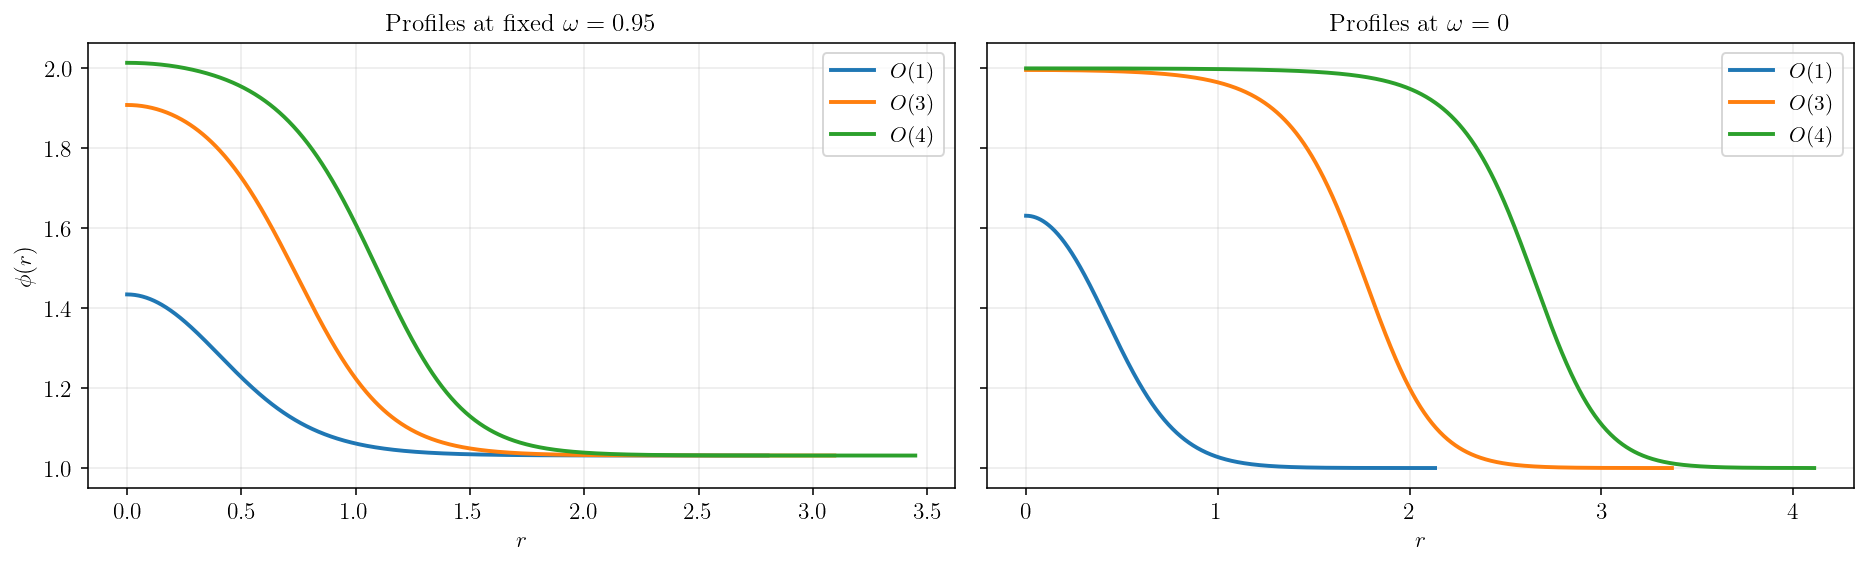

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)

for d in DIMENSIONS:
    b = bounces_fixed["omega_ref"][d]
    axes[0].plot(b["r"], b["phi"], label=rf"$O({d})$")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\phi(r)$")
axes[0].set_title(rf"Profiles at fixed $\omega={OMEGA_REF:.2f}$")
axes[0].legend()

for d in DIMENSIONS:
    b = bounces_fixed["omega_zero"][d]
    axes[1].plot(b["r"], b["phi"], label=rf"$O({d})$")
axes[1].set_xlabel(r"$r$")
axes[1].set_title(r"Profiles at $\omega=0$")
axes[1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "bounce_profiles_fixed_and_zero_omega.pdf", bbox_inches="tight")
plt.show()


## 4. One-Dimensional Charge, Energy, and Density Diagnostics

For fixed $\omega$, we report and compare:

- **Charge** $Q$,
- **Physical Minkowski energy** $E_M$,
- **Grand-canonical functional** $F_\omega = E_M - \omega Q$.

In this notebook, physical energy comparisons always use $E_M$. The quantity $F_\omega$ is still useful for fixed-$\omega$ barrier diagnostics. We also plot radial charge and Minkowski-energy density integrands.


1D integrated observables at fixed omega:
  O(1): Q=9.42495384e+01, E_M=1.23971029e+00, F_omega=-8.82973512e+01
  O(3): Q=1.31420513e+02, E_M=6.95099943e+00, F_omega=-1.17898487e+02
  O(4): Q=1.89933044e+02, E_M=1.48908916e+01, F_omega=-1.65545500e+02


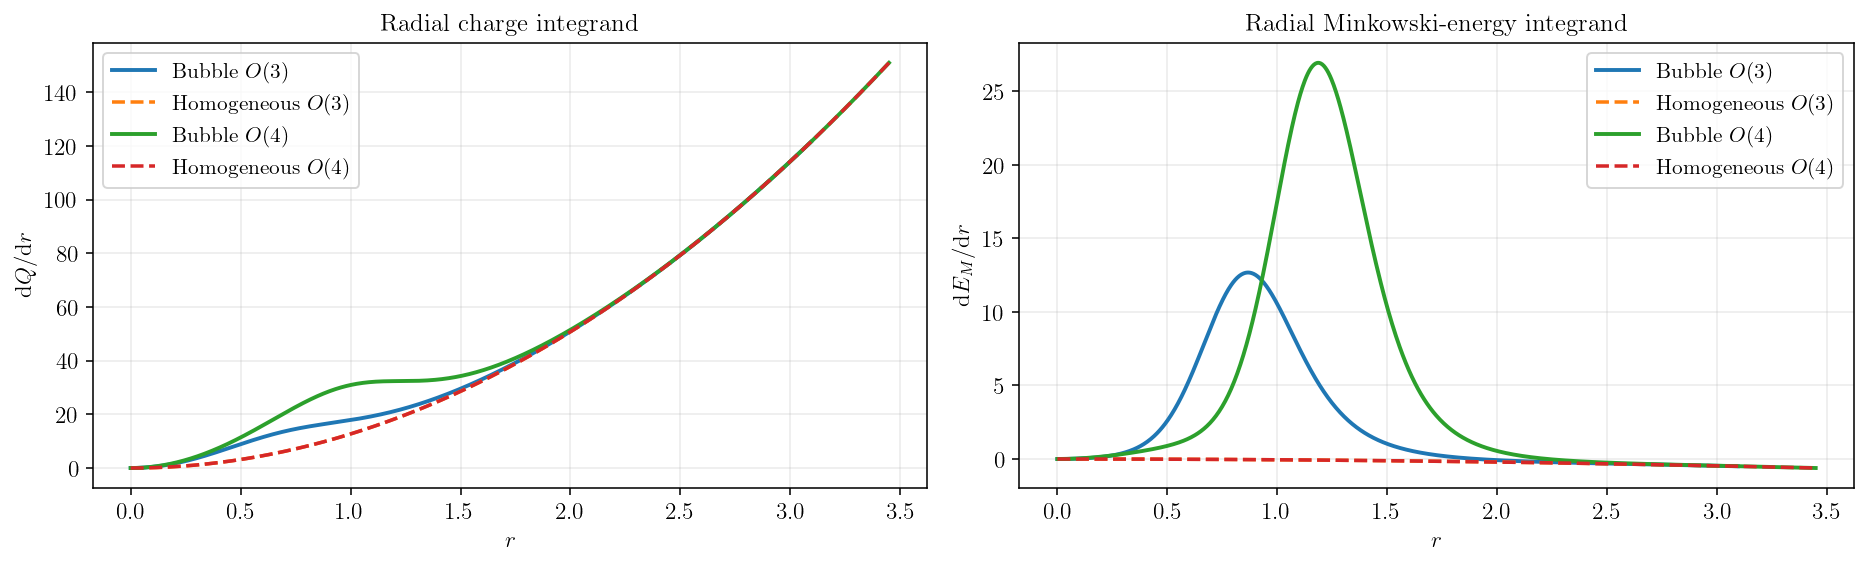

In [75]:
obs_fixed = {}
for d in DIMENSIONS:
    obs_fixed[d] = compute_1d_observables(MODEL, bounces_fixed["omega_ref"][d])

print("1D integrated observables at fixed omega:")
for d in DIMENSIONS:
    o = obs_fixed[d]
    print(f"  O({d}): Q={o['Q']:.8e}, E_M={o['E_M']:.8e}, F_omega={o['F_omega']:.8e}")

# Density-like radial integrands (for visualization)
V_of_rho = lambda rho: V_phi(rho, MODEL.phi0, MODEL.v1, MODEL.v2)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

for d in (3, 4):
    b = bounces_fixed["omega_ref"][d]
    r = b["r"]
    phi = b["phi"]
    phi_hom = float(b["phi_false"])  # homogeneous (false-vacuum) amplitude at the same omega

    dphi = np.gradient(phi, r, edge_order=2)
    dphi[0] = 0.0

    charge_integrand = 4.0 * np.pi * OMEGA_REF * r**2 * phi**2
    energy_integrand = 4.0 * np.pi * r**2 * (
        0.5 * dphi**2 + 0.5 * OMEGA_REF**2 * phi**2 + V_of_rho(phi)
    )

    charge_integrand_hom = 4.0 * np.pi * OMEGA_REF * r**2 * phi_hom**2
    energy_integrand_hom = 4.0 * np.pi * r**2 * (
        0.5 * OMEGA_REF**2 * phi_hom**2 + V_of_rho(phi_hom)
    )

    axes[0].plot(r, charge_integrand, label=rf"Bubble $O({d})$")
    axes[0].plot(r, charge_integrand_hom, "--", lw=1.8, label=rf"Homogeneous $O({d})$")

    axes[1].plot(r, energy_integrand, label=rf"Bubble $O({d})$")
    axes[1].plot(r, energy_integrand_hom, "--", lw=1.8, label=rf"Homogeneous $O({d})$")

axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\mathrm{d}Q/\mathrm{d}r$")
axes[0].set_title(r"Radial charge integrand")
axes[0].legend()

axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\mathrm{d}E_M/\mathrm{d}r$")
axes[1].set_title(r"Radial Minkowski-energy integrand")
axes[1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "one_dimensional_density_profiles.pdf", bbox_inches="tight")
plt.show()


## 5. One-Dimensional Scan in $\omega$

We scan $\omega$ from $0$ up to the maximal range where two distinct vacua of $\Omega(\phi)$ still exist. For each $\omega$ we solve and cache the $O(3)$ and $O(4)$ profiles, then compute key observables.

Main outputs:

- profile evolution with $\omega$,
- bounce center value $\phi(0)$ vs $\omega$,
- $Q(\omega)$,
- $E_M(\omega)$,
- $F_\omega(\omega)$ for reference.


In [59]:
def estimate_omega_max(model: ModelParams, omega_hi: float = 1.2, ntest: int = 240) -> float:
    oms = np.linspace(0.0, omega_hi, ntest)
    ok = []
    for om in oms:
        try:
            vacua_of_Omega(model.phi0, model.v1, model.v2, float(om), verbose=False)
            ok.append(True)
        except Exception:
            ok.append(False)
    ok = np.asarray(ok, dtype=bool)
    if not np.any(ok):
        raise RuntimeError("No valid omega found in tested range")
    last = np.where(ok)[0][-1]
    return float(oms[last])

OMEGA_MAX = estimate_omega_max(MODEL)
omega_scan = np.linspace(0.0, 0.98 * OMEGA_MAX, 22)
print(f"Estimated omega_max ~ {OMEGA_MAX:.6f}")
print(f"Scan points: {len(omega_scan)} in [0, {omega_scan[-1]:.6f}]")

scan_profiles = run_1d_scan(
    CFG["cache_1d_dir"],
    MODEL,
    omega_values=omega_scan,
    dimensions=(3, 4),
    rmax=260.0,
    n_grid_points=1300,
    max_iter=170,
    verbose=False,
)

scan_summary = {3: [], 4: []}
for d in (3, 4):
    for b in scan_profiles[d]:
        obs = compute_1d_observables(MODEL, b)
        scan_summary[d].append(
            {
                "omega": b["omega"],
                "phi_center": b["phi0_center"],
                "phi_false": b["phi_false"],
                "phi_true": b["phi_true"],
                **obs,
            }
        )

for d in (3, 4):
    scan_summary[d] = sorted(scan_summary[d], key=lambda x: x["omega"])

print(f"Converged points: O(3)={len(scan_summary[3])}, O(4)={len(scan_summary[4])}")


Estimated omega_max ~ 1.200000
Scan points: 22 in [0, 1.176000]
Converged points: O(3)=22, O(4)=22


### Volume correction and homogeneous reference along the scan

The integrated quantities $Q$, $E_M$, and $F_\omega$ depend on the integration volume. To compare different $\omega$ values consistently, we recompute all scan observables on a common reference volume $V_{\mathrm{ref}}=\frac{4\pi}{3}R_{\mathrm{ref}}^3$, where $R_{\mathrm{ref}}$ is fixed once for the full scan.

We also compute the corresponding homogeneous-configuration curves at the same $\omega$ values and on the same reference volume.


In [60]:
# Common reference volume for scan comparisons
all_rmax = [float(b["r"][-1]) for d in (3, 4) for b in scan_profiles[d] if len(b["r"]) > 0]
R_REF_SCAN = float(max(all_rmax))
V_REF_SCAN = (4.0 / 3.0) * np.pi * R_REF_SCAN**3

scan_summary_corr = {3: [], 4: []}
scan_homogeneous = {3: [], 4: []}

for d in (3, 4):
    for b in scan_profiles[d]:
        # Bubble observables corrected to a common reference volume
        obs_corr = compute_1d_observables(MODEL, b, r_max_ref=R_REF_SCAN)

        # Homogeneous observables at same omega and same reference volume
        om = float(b["omega"])
        phi_false_om = float(b["phi_false"])
        Q_hom = 4.0 * np.pi * om * phi_false_om**2 * (R_REF_SCAN**3 / 3.0)
        E_M_hom = V_REF_SCAN * (0.5 * om**2 * phi_false_om**2 + V_phi(phi_false_om, MODEL.phi0, MODEL.v1, MODEL.v2))
        F_hom = E_M_hom - om * Q_hom

        scan_summary_corr[d].append(
            {
                "omega": om,
                "phi_center": float(b["phi0_center"]),
                "phi_false": phi_false_om,
                "phi_true": float(b["phi_true"]),
                "Q": float(obs_corr["Q"]),
                "E_M": float(obs_corr["E_M"]),
                "F_omega": float(obs_corr["F_omega"]),
            }
        )

        scan_homogeneous[d].append(
            {
                "omega": om,
                "phi_false": phi_false_om,
                "Q": float(Q_hom),
                "E_M": float(E_M_hom),
                "F_omega": float(F_hom),
            }
        )

for d in (3, 4):
    scan_summary_corr[d] = sorted(scan_summary_corr[d], key=lambda x: x["omega"])
    scan_homogeneous[d] = sorted(scan_homogeneous[d], key=lambda x: x["omega"])

print(f"Reference radius for scan correction: R_ref = {R_REF_SCAN:.6f}")
print(f"Reference volume: V_ref = {V_REF_SCAN:.6e}")


Reference radius for scan correction: R_ref = 4.397022
Reference volume: V_ref = 3.560940e+02


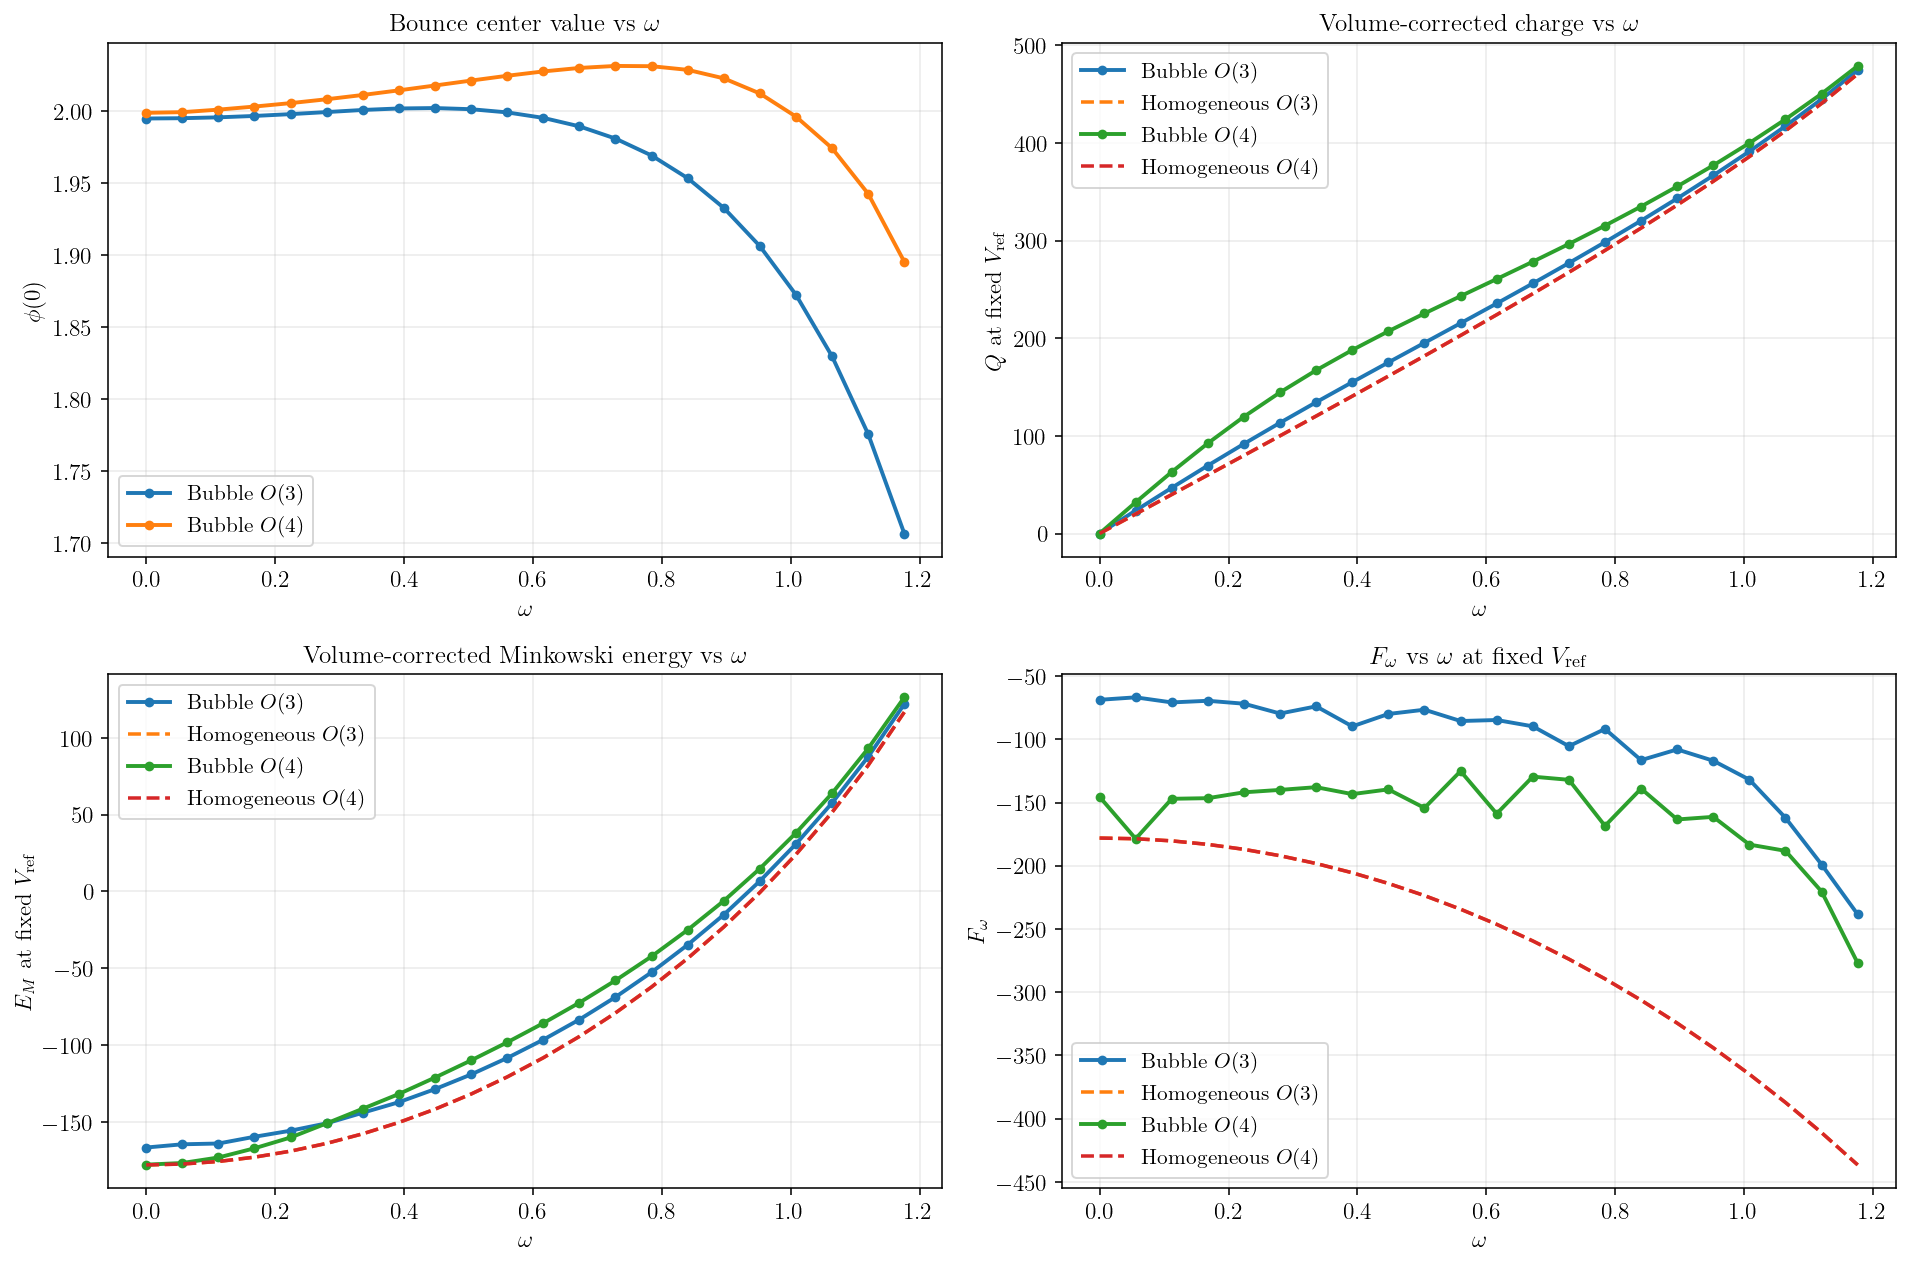

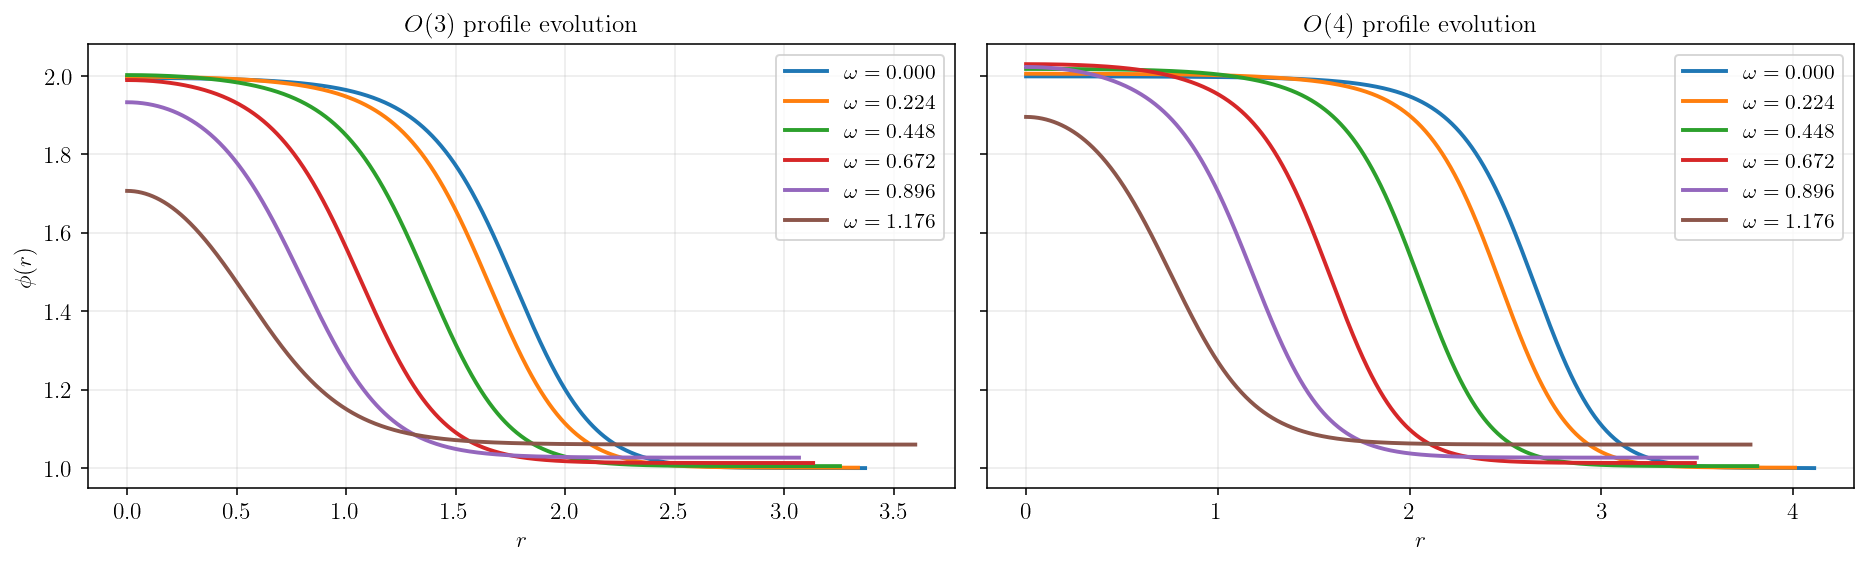

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.2))

for d in (3, 4):
    data = scan_summary_corr[d]
    hom = scan_homogeneous[d]

    om = np.array([x["omega"] for x in data])
    phi0c = np.array([x["phi_center"] for x in data])
    Qs = np.array([x["Q"] for x in data])
    EMs = np.array([x["E_M"] for x in data])
    Fw = np.array([x["F_omega"] for x in data])

    Qh = np.array([x["Q"] for x in hom])
    EMh = np.array([x["E_M"] for x in hom])
    Fh = np.array([x["F_omega"] for x in hom])

    axes[0, 0].plot(om, phi0c, marker="o", ms=4, label=rf"Bubble $O({d})$")

    axes[0, 1].plot(om, Qs, marker="o", ms=4, label=rf"Bubble $O({d})$")
    axes[0, 1].plot(om, Qh, ls="--", lw=1.8, label=rf"Homogeneous $O({d})$")

    axes[1, 0].plot(om, EMs, marker="o", ms=4, label=rf"Bubble $O({d})$")
    axes[1, 0].plot(om, EMh, ls="--", lw=1.8, label=rf"Homogeneous $O({d})$")

    axes[1, 1].plot(om, Fw, marker="o", ms=4, label=rf"Bubble $O({d})$")
    axes[1, 1].plot(om, Fh, ls="--", lw=1.8, label=rf"Homogeneous $O({d})$")

axes[0, 0].set_title(r"Bounce center value vs $\omega$")
axes[0, 0].set_xlabel(r"$\omega$")
axes[0, 0].set_ylabel(r"$\phi(0)$")
axes[0, 0].legend()

axes[0, 1].set_title(r"Volume-corrected charge vs $\omega$")
axes[0, 1].set_xlabel(r"$\omega$")
axes[0, 1].set_ylabel(r"$Q$ at fixed $V_{\mathrm{ref}}$")
axes[0, 1].legend()

axes[1, 0].set_title(r"Volume-corrected Minkowski energy vs $\omega$")
axes[1, 0].set_xlabel(r"$\omega$")
axes[1, 0].set_ylabel(r"$E_M$ at fixed $V_{\mathrm{ref}}$")
axes[1, 0].legend()

axes[1, 1].set_title(r"$F_\omega$ vs $\omega$ at fixed $V_{\mathrm{ref}}$")
axes[1, 1].set_xlabel(r"$\omega$")
axes[1, 1].set_ylabel(r"$F_\omega$")
axes[1, 1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "one_dimensional_omega_scan_observables.pdf", bbox_inches="tight")
plt.show()

# Profile evolution (clean subset to avoid clutter)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)
for d, ax in zip((3, 4), axes):
    records = scan_summary_corr[d]
    pick = np.linspace(0, len(records) - 1, 6, dtype=int)
    for idx in pick:
        rec = records[idx]
        b = next(bb for bb in scan_profiles[d] if abs(bb["omega"] - rec["omega"]) < 1e-12)
        ax.plot(b["r"], b["phi"], label=rf"$\omega={rec['omega']:.3f}$")
    ax.set_title(rf"$O({d})$ profile evolution")
    ax.set_xlabel(r"$r$")
    ax.legend()
axes[0].set_ylabel(r"$\phi(r)$")
fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "one_dimensional_profile_evolution.pdf", bbox_inches="tight")
plt.show()


## 6. Two-Dimensional Problem: Conventions and Solver Logic

We now move to the Euclidean 2D problem in $(r,\tau)$ with half-interval in Euclidean time. The solver uses rotated variables and two partner fields $(y,\bar y)$.

The key mapping is:

$$
\phi_{\mathrm{rot}} = \rho_0 + \frac{y}{r},\qquad
\bar\phi_{\mathrm{rot}} = \rho_0 + \frac{\bar y}{r},
$$

with twisted closure at $\tau=-\beta/2$ and reflection/swap at $\tau=0$.

The Newton method solves the nonlinear residual on the full 2D grid. The twist parameter $\eta_0$ is scanned (with a bracketing/root procedure) so that the final 2D solution matches a chosen target charge.

Seed quality is crucial: we compare four seed families with a unified interface and the same downstream solver pipeline.


## 7. Default 2D Grid and Solver Parameters

Default analysis values are centralized here:

- $L_r = 5$,
- $\beta = 10$,
- grid approximately $60\times 60$,
- one central dictionary for Newton/twist options.

These defaults are used consistently in all seed subsections unless explicitly overridden.


In [103]:
# 2D default configuration (centralized)
# IMPORTANT: force the homogeneous background to the FALSE vacuum branch.
phi_false_2d, phi_true_2d = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(OMEGA_REF), verbose=False)
rho0_false_solver_units = float(phi_false_2d / np.sqrt(2.0))

CFG_2D = {
    "Nr": 120,
    "Ntau": 120,
    "Lr": 5.0,
    "beta": 10.0,
    "omega_ref": float(OMEGA_REF),
    "eta0_init": 0.0,
    "newton_tol": 1e-8,
    "newton_max_iter": 45,
    "damping": 0.8,
    "max_backtracks": 28,
    "rho0_bracket": (0.6, 1.6),
    "rho0_false": rho0_false_solver_units,
    "complex_saddle": True,
    "verbose": True,
}

# Build potential backend for 2D solver from project functions
U, dU, d2U = make_potential_from_V(
    V_phi,
    dV_dphi,
    d2V_dphi2,
    MODEL.phi0,
    MODEL.v1,
    MODEL.v2,
)

# 1D profiles used to build the 2D seed families at fixed omega
profiles_for_seeds = {
    "O1": bounces_fixed["omega_ref"][1],
    "O3": bounces_fixed["omega_ref"][3],
    "O4": bounces_fixed["omega_ref"][4],
}

# Target charge on the current 2D solver/grid (same convention as SeedSearch_NewAnsatz)
_solver_target = Bubble2DSolver(
    Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=CFG_2D["beta"],
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(CFG_2D["eta0_init"]),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=False,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    ),
    U,
    dU,
    d2U,
)
_targets_2d = compute_targets_tau0_ghost(
    _solver_target,
    subtract_background_charge=False,
)
Q_TARGET_2D = float(_targets_2d["Q"])

# Keep the previous 1D-based estimate for reference/diagnostics
Q_TARGET_2D_FROM_1D = compute_1d_observables(
    MODEL,
    bounces_fixed["omega_ref"][3],
    r_max_ref=CFG_2D["Lr"],
)["Q"]

print(f"2D vacua at omega_ref: phi_false={phi_false_2d:.10e}, phi_true={phi_true_2d:.10e}")
print(f"Forced solver rho0 (|phi| units): {CFG_2D['rho0_false']:.10e}")
print(f"Forced homogeneous rho_phys = sqrt(2)*rho0: {np.sqrt(2.0)*CFG_2D['rho0_false']:.10e}")
print(f"Target charge for 2D eta0 scan (current 2D grid): Q_target = {Q_TARGET_2D:.10e}")
print(f"Reference 1D O(3) volume-corrected target:          Q_1d_ref = {Q_TARGET_2D_FROM_1D:.10e}")


2D vacua at omega_ref: phi_false=1.0312018015e+00, phi_true=2.0656590991e+00
Forced solver rho0 (|phi| units): 7.2916978659e-01
Forced homogeneous rho_phys = sqrt(2)*rho0: 1.0312018015e+00
Target charge for 2D eta0 scan (current 2D grid): Q_target = 5.2894352146e+02
Reference 1D O(3) volume-corrected target:          Q_1d_ref = 5.3498049142e+02


## 8. Unified 2D Seed System

We define four seed types through a single interface `build_seed(...)`:

1. `O4_seed`: profile based on $\rho_E = \sqrt{r^2+\tau^2}$ from the 1D $O(4)$ solution,
2. `O3_static_seed`: 1D $O(3)$ profile in $r$, constant in $\tau$,
3. `O1_tau_seed`: 1D $O(1)$ profile in $|\tau|$, constant in $r$,
4. `homogeneous_seed`: trivial homogeneous false-vacuum seed.

This logic is centralized in `clean_analysis_helpers.py` and reused in all 2D subsections.


In [104]:
def make_solver(eta0: float = 0.0, verbose: bool = True) -> Bubble2DSolver:
    settings = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=CFG_2D["beta"],
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(eta0),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=bool(verbose),
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )
    return Bubble2DSolver(settings, U, dU, d2U)

SEED_TYPES = ["O4_seed", "O3_static_seed", "O1_tau_seed", "homogeneous_seed"]
seed_preview = {}
solver_preview = make_solver(eta0=0.0, verbose=False)
for s in SEED_TYPES:
    x0, rho_seed = build_seed(solver_preview, s, profiles_for_seeds)
    seed_preview[s] = {"x0": x0, "rho_seed": rho_seed}

print("Seed system initialized for:")
for s in SEED_TYPES:
    arr = seed_preview[s]["rho_seed"]
    print(f"  {s:<18} shape={arr.shape}, min={arr.min():.6f}, max={arr.max():.6f}")


Seed system initialized for:
  O4_seed            shape=(120, 120), min=0.729170, max=1.423032
  O3_static_seed     shape=(120, 120), min=0.729170, max=1.348052
  O1_tau_seed        shape=(120, 120), min=0.729170, max=1.013593
  homogeneous_seed   shape=(120, 120), min=0.729170, max=0.729170


## 9. Focus Study: O(4)-Inspired Seed

Before the full multi-seed comparison, we first construct and validate the `O4_seed` carefully. We inspect:

- the full 2D seed map,
- the $r=0$ slice vs $\tau$,
- the $\tau=0$ slice vs $r$,

and compare these with one-dimensional reference profiles ($O(4)$, $O(3)$, $O(1)$) to confirm consistency of the construction.


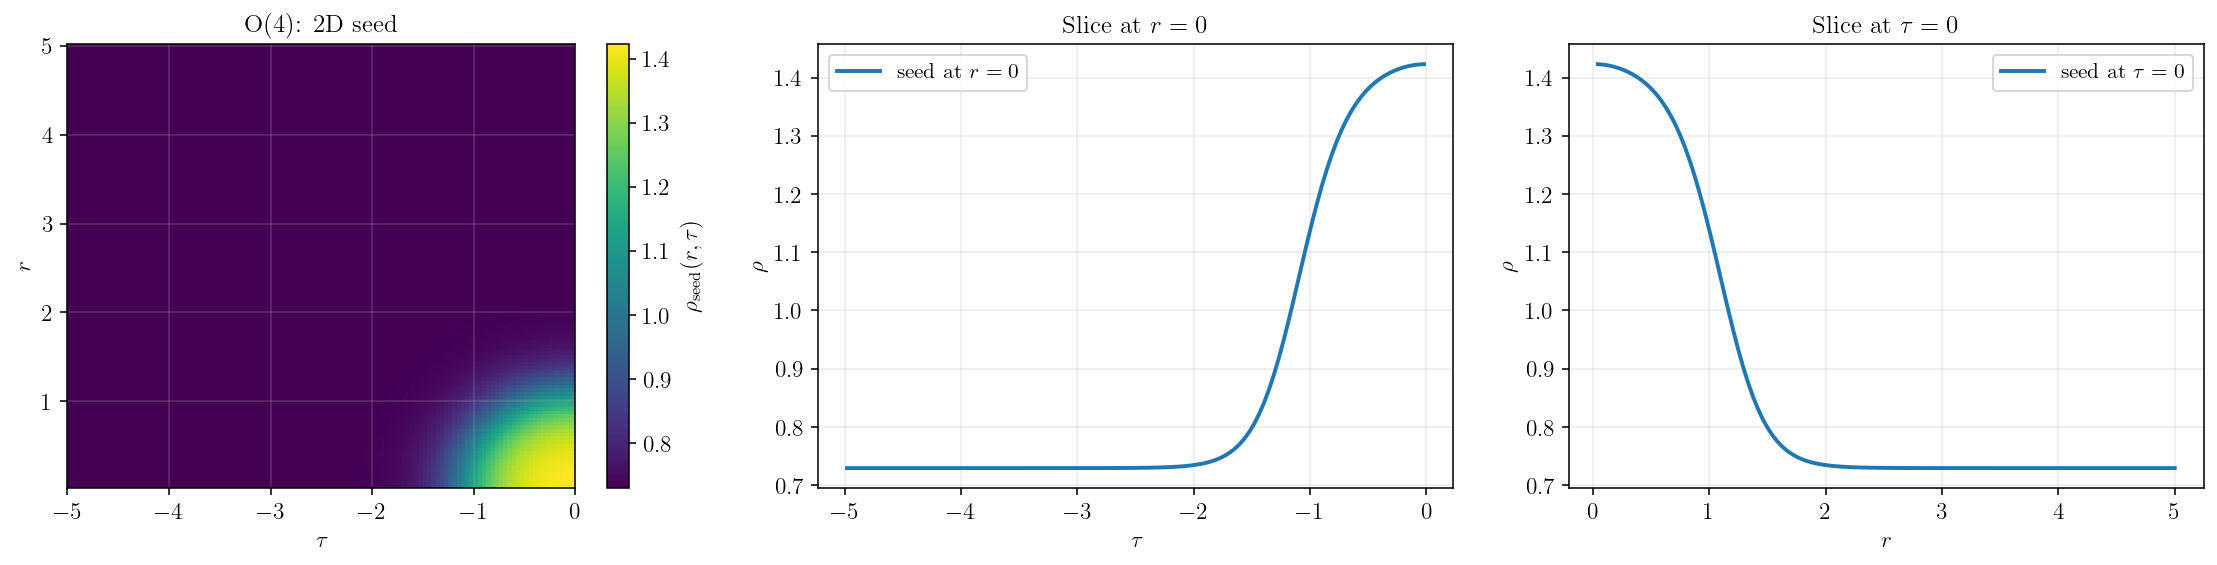

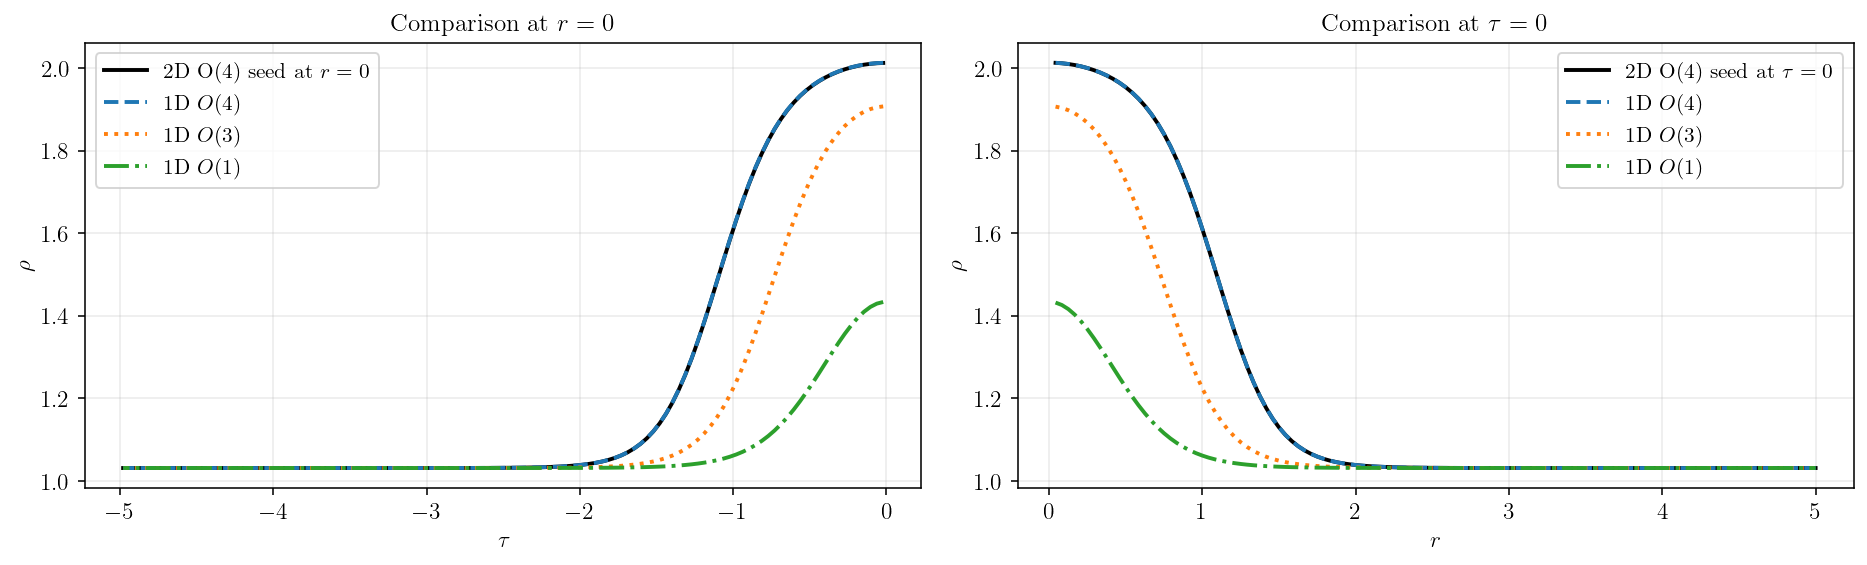

In [105]:
solver_o4_seed = make_solver(eta0=0.0, verbose=False)
x0_o4_seed, rho_o4_seed = build_seed(solver_o4_seed, "O4_seed", profiles_for_seeds)

r2d = np.asarray(solver_o4_seed.grid.r, dtype=float)
tau2d = np.asarray(solver_o4_seed.grid.tau, dtype=float)

fig, _ = plot_seed_maps(r2d, tau2d, rho_o4_seed, title_prefix="O(4)")
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "seed_O4_overview.pdf", bbox_inches="tight")
plt.show()

# Explicit seed-vs-1D comparisons
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))

# r=0 slice as a function of tau
ax[0].plot(tau2d, np.sqrt(2)*rho_o4_seed[0, :], label=r"2D O(4) seed at $r=0$", color="k")
ax[0].plot(tau2d, np.interp(np.abs(tau2d), bounces_fixed["omega_ref"][4]["r"], bounces_fixed["omega_ref"][4]["phi"]), ls="--", label=r"1D $O(4)$")
ax[0].plot(tau2d, np.interp(np.abs(tau2d), bounces_fixed["omega_ref"][3]["r"], bounces_fixed["omega_ref"][3]["phi"]), ls=":", label=r"1D $O(3)$")
ax[0].plot(tau2d, np.interp(np.abs(tau2d), bounces_fixed["omega_ref"][1]["r"], bounces_fixed["omega_ref"][1]["phi"]), ls="-.", label=r"1D $O(1)$")
ax[0].set_xlabel(r"$\tau$")
ax[0].set_ylabel(r"$\rho$")
ax[0].set_title(r"Comparison at $r=0$")
ax[0].legend()

# tau=0 slice as a function of r
ax[1].plot(r2d, np.sqrt(2)*rho_o4_seed[:, 0], label=r"2D O(4) seed at $\tau=0$", color="k")
ax[1].plot(r2d, np.interp(r2d, bounces_fixed["omega_ref"][4]["r"], bounces_fixed["omega_ref"][4]["phi"]), ls="--", label=r"1D $O(4)$")
ax[1].plot(r2d, np.interp(r2d, bounces_fixed["omega_ref"][3]["r"], bounces_fixed["omega_ref"][3]["phi"]), ls=":", label=r"1D $O(3)$")
ax[1].plot(r2d, np.interp(r2d, bounces_fixed["omega_ref"][1]["r"], bounces_fixed["omega_ref"][1]["phi"]), ls="-.", label=r"1D $O(1)$")
ax[1].set_xlabel(r"$r$")
ax[1].set_ylabel(r"$\rho$")
ax[1].set_title(r"Comparison at $\tau=0$")
ax[1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "seed_O4_vs_1d_profiles.pdf", bbox_inches="tight")
plt.show()


## 10. 2D Newton Solve from O(4) Seed and $\eta_0$ Scan

Starting from the $O(4)$-inspired seed, we first run a full Newton solve at $\eta_0=0$ with verbose output.

Then we scan $\eta_0$ in fixed steps from that point, detect the first charge-sign crossing relative to $Q_{\mathrm{target}}$, and finally refine with `brentq` while continuously warm-starting from the last Newton state.

We store diagnostics $(\eta_0, Q, E, \|F\|)$ for post-analysis.


In [106]:
def _solve_at_eta_local(slv, eta, x_init, verbose=False):
    import io
    import re
    from contextlib import redirect_stdout

    slv.settings.eta0 = float(eta)
    slv.eta0 = float(eta)

    # Keep first Newton in verbose mode, but reprint only compact diagnostics.
    if verbose:
        buf = io.StringIO()
        with redirect_stdout(buf):
            sol_eta = slv.solve(x_init, verbose=True, verbose_success_block=False)

        raw_log = buf.getvalue().splitlines()
        pat = re.compile(
            r"iter=(\d+).*?\|\|F\|\|=([+\-0-9.eE]+).*?rhoQ=([+\-0-9.eE]+).*?rhoE=([+\-0-9.eE]+).*?"
            r"rho_Q/rho_Q_ref=([+\-0-9.eE]+).*?rho_E/rho_E_ref=([+\-0-9.eE]+)"
        )
        for line in raw_log:
            if "[Newton-explicit]" not in line:
                continue
            m = pat.search(line)
            if m is None:
                continue
            it = int(m.group(1))
            nF = float(m.group(2))
            q_val = float(m.group(3))
            e_val = float(m.group(4))
            q_ratio = float(m.group(5))
            e_ratio = float(m.group(6))
            print(
                f"[Newton-compact] iter={it:02d}  ||F||={nF:.3e}  Q={q_val:.8e}  E={e_val:.8e}  "
                f"Q/Q*= {q_ratio:.6f}  E/E*= {e_ratio:.6f}"
            )
    else:
        sol_eta = slv.solve(x_init, verbose=False, verbose_success_block=False)

    q_eta = float(
        compute_charge_tau0_ghost_2d(
            slv,
            sol_eta.y,
            sol_eta.ybar,
            subtract_background=False,
        )
    )
    e_eta = float(sol_eta.E_tau0)
    r_eta = float(sol_eta.residual_norm)
    return q_eta, e_eta, r_eta, sol_eta


def _eta_scan_match_charge_local(
    slv,
    x_seed,
    Q_target_here,
    eta_start=0.0,
    d_eta=0.02,
    max_steps=80,
    tol_q=1e-6,
    scan_label="eta-scan",
):
    tol_abs = float(tol_q * max(1.0, abs(Q_target_here)))
    history = []

    targets = compute_targets_tau0_ghost(slv, subtract_background_charge=False)
    Q_target = float(targets["Q"])
    E_target = float(targets["E"])

    print("[Targets] eta0 scan references:")
    print(f"  Q_target = {Q_target:.8e}")
    print(f"  E_target = {E_target:.8e}")

    def _print_compact_line(tag, eta, q_val, e_val):
        q_ratio = q_val / Q_target if abs(Q_target) > 1e-30 else np.nan
        e_ratio = e_val / E_target if abs(E_target) > 1e-30 else np.nan
        print(
            f"[{tag}] eta={eta:.6f}  Q={q_val:.8e}  E={e_val:.8e}  "
            f"Q/Q*= {q_ratio:.6f}  E/E*= {e_ratio:.6f}"
        )

    # First solve at eta=0 with full Newton verbose output
    eta_curr = float(eta_start)
    q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=True)
    x_seed = np.asarray(sol_curr.x, dtype=float).copy()
    history.append({"eta0": eta_curr, "Q": q_curr, "E": e_curr, "residual": r_curr})

    _print_compact_line(scan_label, eta_curr, q_curr, e_curr)
    if abs(q_curr - Q_target_here) <= tol_abs:
        return sol_curr, {
            "eta0": eta_curr,
            "eta_bracket_used": (eta_curr, eta_curr),
            "history": history,
        }

    eta_prev, q_prev = eta_curr, q_curr
    crossed = False

    # Step scan from eta=0, no initial global bracketing
    for _ in range(int(max_steps)):
        eta_prev, q_prev = eta_curr, q_curr
        if q_curr < Q_target_here:
            eta_curr += d_eta
        else:
            eta_curr -= d_eta

        q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False)
        x_seed = np.asarray(sol_curr.x, dtype=float).copy()
        history.append({"eta0": eta_curr, "Q": q_curr, "E": e_curr, "residual": r_curr})
        _print_compact_line(scan_label, eta_curr, q_curr, e_curr)

        if (q_prev - Q_target_here) * (q_curr - Q_target_here) <= 0:
            crossed = True
            break

    if not crossed:
        raise RuntimeError("O4 eta-scan did not cross target charge within max_steps")

    eta_lo, eta_hi = (eta_prev, eta_curr) if eta_prev < eta_curr else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}
    cache = {}

    def _f_eta(eta):
        key = round(float(eta), 12)
        if key in cache:
            return cache[key]["Q"] - Q_target_here

        q_val, e_val, r_val, sol_val = _solve_at_eta_local(slv, float(eta), state["x_seed"], verbose=False)
        state["x_seed"] = np.asarray(sol_val.x, dtype=float).copy()
        cache[key] = {"Q": q_val, "E": e_val, "residual": r_val}
        history.append({"eta0": float(eta), "Q": q_val, "E": e_val, "residual": r_val})
        return q_val - Q_target_here

    eta_star = float(brentq(_f_eta, eta_lo, eta_hi, xtol=1e-10))
    q_star, e_star, r_star, sol_star = _solve_at_eta_local(slv, eta_star, state["x_seed"], verbose=False)
    history.append({"eta0": eta_star, "Q": q_star, "E": e_star, "residual": r_star})

    _print_compact_line(f"{scan_label}*", eta_star, q_star, e_star)

    return sol_star, {
        "eta0": eta_star,
        "eta_bracket_used": (eta_lo, eta_hi),
        "history": history,
    }


def _resample_seed_to_solver_grid(old_solver, new_solver, x_old):
    """
    Resample a full 2D state preserving complex structure (y, ybar),
    then repack in the new solver representation.

    This avoids losing phase information that would be dropped by rho-only resampling.
    """
    y_old, ybar_old = old_solver.unpack(np.asarray(x_old))

    r_old = np.asarray(old_solver.grid.r, dtype=float)
    tau_old = np.asarray(old_solver.grid.tau, dtype=float)
    r_new = np.asarray(new_solver.grid.r, dtype=float)
    tau_new = np.asarray(new_solver.grid.tau, dtype=float)

    def _interp_complex(field_old: np.ndarray) -> np.ndarray:
        f_re = RegularGridInterpolator(
            (r_old, tau_old),
            np.asarray(field_old.real, dtype=float),
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        f_im = RegularGridInterpolator(
            (r_old, tau_old),
            np.asarray(field_old.imag, dtype=float),
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        RR, TT = np.meshgrid(r_new, tau_new, indexing="ij")
        pts = np.column_stack([RR.ravel(), TT.ravel()])
        re_new = f_re(pts).reshape((r_new.size, tau_new.size))
        im_new = f_im(pts).reshape((r_new.size, tau_new.size))
        return re_new + 1j * im_new

    y_new = _interp_complex(np.asarray(y_old))
    ybar_new = _interp_complex(np.asarray(ybar_old))

    return new_solver.pack(y_new, ybar_new)


def _prepare_seed_for_solver_grid(solver_target, x_seed, solver_source=None, label="seed"):
    try:
        _ = solver_target.unpack(np.asarray(x_seed))
        return np.asarray(x_seed).copy()
    except Exception:
        if solver_source is None:
            raise RuntimeError(f"[{label}] incompatible seed and no source solver provided for resampling.")
        x_resampled = _resample_seed_to_solver_grid(solver_source, solver_target, x_seed)
        return x_resampled


solver_o4 = make_solver(eta0=0.0, verbose=True)
x0_o4_native, rho_seed_o4_native = build_seed(solver_o4, "O4_seed", profiles_for_seeds)

# Align with SeedSearch workflow: optionally reuse preview seed and enforce grid compatibility.
x0_candidate = np.asarray(x0_o4_native).copy()
solver_candidate = solver_o4
if "x0_o4_seed" in globals():
    x0_candidate = np.asarray(x0_o4_seed).copy()
if "solver_o4_seed" in globals():
    solver_candidate = solver_o4_seed

x0_o4 = _prepare_seed_for_solver_grid(
    solver_target=solver_o4,
    x_seed=x0_candidate,
    solver_source=solver_candidate,
    label="O4",
)

y_o4_seed, yb_o4_seed = solver_o4.unpack(np.asarray(x0_o4))
rho_seed_o4 = np.asarray(solver_o4.rho_map(y_o4_seed, yb_o4_seed), dtype=float)

sol_o4, meta_o4 = _eta_scan_match_charge_local(
    solver_o4,
    x0_o4,
    Q_TARGET_2D,
    eta_start=0.0,
    d_eta=0.05,
    max_steps=80,
    tol_q=1e-6,
)

summary_o4 = summarize_solution(sol_o4)
print("\nFinal O(4)-seed solution summary:")
for k, v in summary_o4.items():
    print(f"  {k}: {v}")

print(f"\neta0* from scan metadata: {meta_o4.get('eta0', np.nan)}")


[Targets] eta0 scan references:
  Q_target = 5.28943521e+02
  E_target = 2.15220255e+00
[Newton-compact] iter=01  ||F||=2.144e+01  Q=1.04154700e+00  E=-2.56372000e-02  Q/Q*= 1.031000  E/E*= -6.237100
[Newton-compact] iter=02  ||F||=1.519e+01  Q=1.03107100e+00  E=-1.46027300e-02  Q/Q*= 1.020700  E/E*= -3.552600
[Newton-compact] iter=03  ||F||=1.209e+01  Q=1.02560300e+00  E=-8.38402000e-03  Q/Q*= 1.015200  E/E*= -2.039700
[Newton-compact] iter=04  ||F||=2.932e+00  Q=1.01757700e+00  E=-2.30701000e-03  Q/Q*= 1.007300  E/E*= -0.561300
[Newton-compact] iter=05  ||F||=5.278e-01  Q=1.01729700e+00  E=-2.58681300e-03  Q/Q*= 1.007000  E/E*= -0.629300
[Newton-compact] iter=06  ||F||=5.895e-03  Q=1.01728200e+00  E=-2.61184800e-03  Q/Q*= 1.007000  E/E*= -0.635400
[Newton-compact] iter=07  ||F||=2.929e-06  Q=1.01728200e+00  E=-2.61245300e-03  Q/Q*= 1.007000  E/E*= -0.635600
[Newton-compact] iter=08  ||F||=2.962e-12  Q=1.01728200e+00  E=-2.61245300e-03  Q/Q*= 1.007000  E/E*= -0.635600
[eta-scan] eta=0

## 11. Final O(4)-Based 2D Solution and 1D Comparisons

After convergence, we show the full 2D profile and compare the two key slices with 1D $O(4)$, $O(3)$, and $O(1)$ profiles.

This provides a direct geometric interpretation of how the final 2D saddle relates to the one-dimensional reduced solutions.


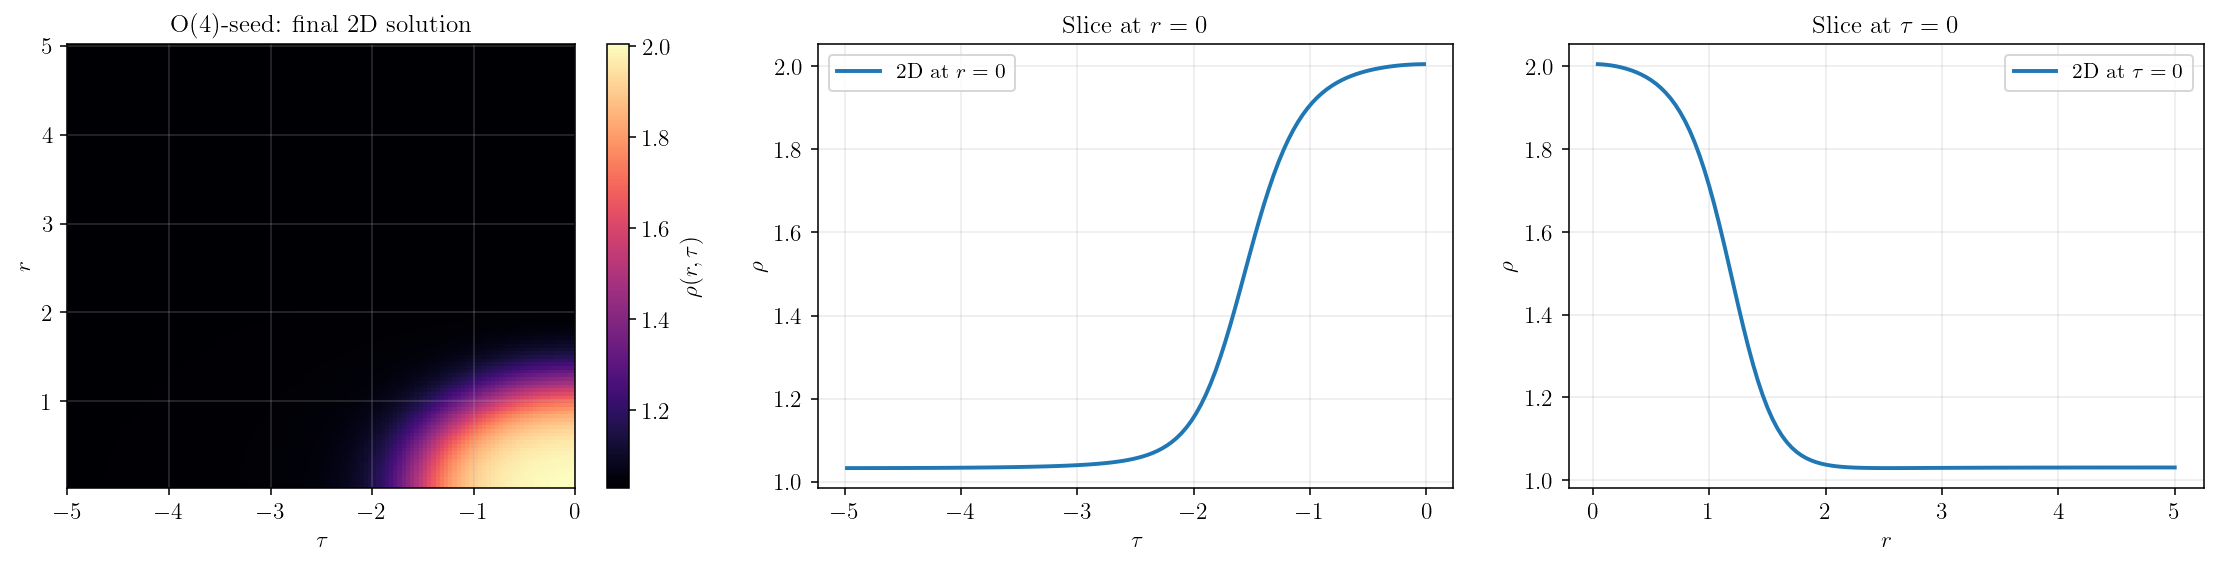

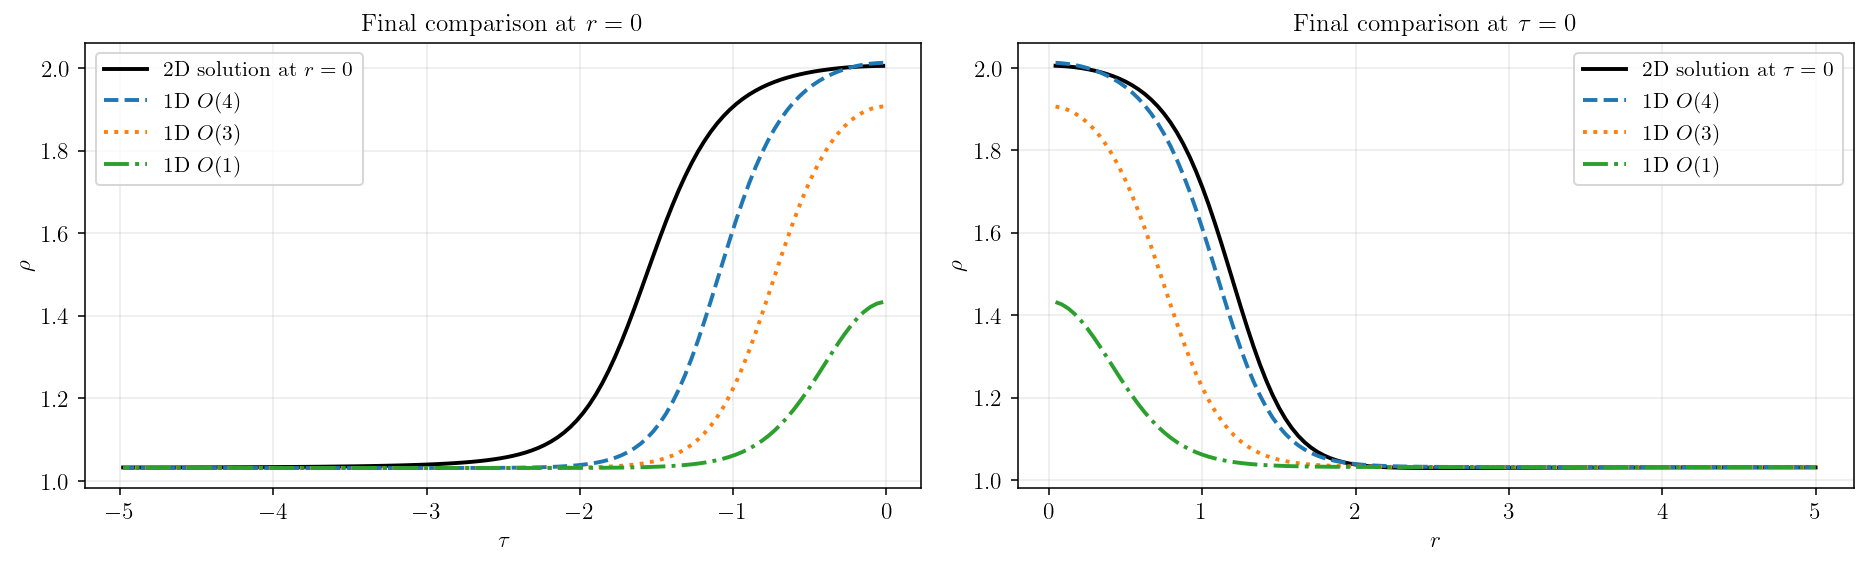

In [107]:
rho_o4_final = solver_o4.rho_map(sol_o4.y, sol_o4.ybar)
r2d = np.asarray(solver_o4.grid.r, dtype=float)
tau2d = np.asarray(solver_o4.grid.tau, dtype=float)

fig, _ = plot_solution_maps(r2d, tau2d, rho_o4_final, title_prefix="O(4)-seed")
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o4_final_solution_map.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))

# r=0 comparison
ax[0].plot(tau2d, rho_o4_final[0, :], color="k", label=r"2D solution at $r=0$")
for d, style in zip((4, 3, 1), ("--", ":", "-.")):
    b = bounces_fixed["omega_ref"][d]
    ax[0].plot(tau2d, np.interp(np.abs(tau2d), b["r"], b["phi"]), style, label=rf"1D $O({d})$")
ax[0].set_xlabel(r"$\tau$")
ax[0].set_ylabel(r"$\rho$")
ax[0].set_title(r"Final comparison at $r=0$")
ax[0].legend()

# tau=0 comparison
ax[1].plot(r2d, rho_o4_final[:, 0], color="k", label=r"2D solution at $\tau=0$")
for d, style in zip((4, 3, 1), ("--", ":", "-.")):
    b = bounces_fixed["omega_ref"][d]
    ax[1].plot(r2d, np.interp(r2d, b["r"], b["phi"]), style, label=rf"1D $O({d})$")
ax[1].set_xlabel(r"$r$")
ax[1].set_ylabel(r"$\rho$")
ax[1].set_title(r"Final comparison at $\tau=0$")
ax[1].legend()

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o4_final_vs_1d_profiles.pdf", bbox_inches="tight")
plt.show()


## 12. Energy Decomposition in Terms of $\rho_{\mathrm{phys}}$ and $\beta$

This section rewrites the energy of the final O(4)-based 2D solution directly in terms of the physical modulus $\rho_{\mathrm{phys}}(r,\tau)$ and the phase variable $\beta(r,\tau)$.

We start from the solved fields $\phi(r,\tau)$ and $\bar\phi(r,\tau)$ and define
$$
u(r,\tau)=\mathrm{Re}\!\big[\phi(r,\tau)\bar\phi(r,\tau)\big],
\qquad
\rho_{\mathrm{phys}}(r,\tau)=\sqrt{2u(r,\tau)+\rho_\epsilon},
$$
with radial measure
$$
4\pi\int dr\,r^2(\cdots).
$$

In these conventions, the fields are locally written as
$$
\phi(r,\tau)=\frac{\rho_{\mathrm{phys}}(r,\tau)}{\sqrt{2}}\,e^{\beta(r,\tau)},
\qquad
\bar\phi(r,\tau)=\frac{\rho_{\mathrm{phys}}(r,\tau)}{\sqrt{2}}\,e^{-\beta(r,\tau)}.
$$

With this parametrization, the radial and Euclidean-time derivative terms decompose as
$$
(\partial_r\phi)(\partial_r\bar\phi)
=
\frac12(\partial_r\rho_{\mathrm{phys}})^2
-\frac12\rho_{\mathrm{phys}}^2(\partial_r\beta)^2,
$$
and
$$
-(\partial_\tau\phi)(\partial_\tau\bar\phi)
=
-\frac12(\partial_\tau\rho_{\mathrm{phys}})^2
+\frac12\rho_{\mathrm{phys}}^2(\partial_\tau\beta)^2.
$$

Therefore, the full Minkowski energy density becomes
$$
\mathcal E_M
=
\frac12(\partial_r\rho_{\mathrm{phys}})^2
-\frac12\rho_{\mathrm{phys}}^2(\partial_r\beta)^2
+\frac12\rho_{\mathrm{phys}}^2(\partial_\tau\beta)^2
-\frac12(\partial_\tau\rho_{\mathrm{phys}})^2
+
U(\rho_{\mathrm{phys}}).
$$

The purpose of this section is to isolate and plot the sum of **all** energy contributions **except** the temporal-modulus term
$$
\frac12(\partial_\tau\rho_{\mathrm{phys}})^2.
$$

To do so, we reconstruct the phase gradients directly from the solved fields. Using
$$
\bar\phi\,\partial_\mu\phi-\phi\,\partial_\mu\bar\phi
=
\rho_{\mathrm{phys}}^2\,\partial_\mu\beta,
\qquad
\mu=r,\tau,
$$
we obtain
$$
\partial_r\beta
=
\frac{\mathrm{Re}\!\big[\bar\phi\,\partial_r\phi-\phi\,\partial_r\bar\phi\big]}
{\rho_{\mathrm{phys}}^2},
\qquad
\partial_\tau\beta
=
\frac{\mathrm{Re}\!\big[\bar\phi\,\partial_\tau\phi-\phi\,\partial_\tau\bar\phi\big]}
{\rho_{\mathrm{phys}}^2}.
$$

We then define the following individual contributions on each $\tau$ slice:

### Radial modulus-gradient contribution
$$
E_{\rho,r}(\tau)
=
4\pi\int dr\,r^2\,
\frac12(\partial_r\rho_{\mathrm{phys}})^2.
$$

### Spatial phase-gradient contribution
$$
E_{\beta,r}(\tau)
=
4\pi\int dr\,r^2\,
\left[-\frac12\rho_{\mathrm{phys}}^2(\partial_r\beta)^2\right].
$$

### Temporal phase-gradient contribution
$$
E_{\beta,\tau}(\tau)
=
4\pi\int dr\,r^2\,
\frac12\rho_{\mathrm{phys}}^2(\partial_\tau\beta)^2.
$$

### Temporal modulus contribution
$$
E_{\rho,\tau}(\tau)
=
4\pi\int dr\,r^2\,
\frac12(\partial_\tau\rho_{\mathrm{phys}})^2.
$$

### Potential contribution
$$
E_U(\tau)
=
4\pi\int dr\,r^2\,U(\rho_{\mathrm{phys}}).
$$

With these definitions, the full Minkowski energy on each slice is
$$
E_{\mathrm{full}}(\tau)
=
E_{\rho,r}(\tau)
+
E_{\beta,r}(\tau)
+
E_{\beta,\tau}(\tau)
-
E_{\rho,\tau}(\tau)
+
E_U(\tau).
$$

In this section, however, the main quantity of interest is obtained by omitting the temporal-modulus piece:
$$
E_{\mathrm{no}\,\rho_\tau}(\tau)
=
E_{\rho,r}(\tau)
+
E_{\beta,r}(\tau)
+
E_{\beta,\tau}(\tau)
+
E_U(\tau).
$$

This is the energy built from all components except the term proportional to
$$
\frac12(\partial_\tau\rho_{\mathrm{phys}})^2.
$$

### Homogeneous reference
For the homogeneous background one has
$$
\rho_{\mathrm{phys},h}=\sqrt{2}\,\rho_0,
\qquad
\partial_r\rho_{\mathrm{phys},h}=0,
\qquad
\partial_r\beta_h=0,
\qquad
\partial_\tau\rho_{\mathrm{phys},h}=0,
\qquad
\partial_\tau\beta_h=\omega.
$$
Therefore,
$$
E_{\rho,r,h}=0,
\qquad
E_{\beta,r,h}=0,
\qquad
E_{\beta,\tau,h}
=
4\pi\int dr\,r^2\,
\frac12\rho_{\mathrm{phys},h}^2\omega^2,
$$
$$
E_{\rho,\tau,h}=0,
\qquad
E_{U,h}
=
4\pi\int dr\,r^2\,U(\rho_{\mathrm{phys},h}).
$$

Accordingly, the homogeneous reference for the quantity of interest is
$$
E_{\mathrm{no}\,\rho_\tau,h}
=
E_{\beta,\tau,h}+E_{U,h}.
$$

We then plot the corresponding homogeneous-subtracted quantities:
$$
\Delta E_{\rho,r}(\tau),\qquad
\Delta E_{\beta,r}(\tau),\qquad
\Delta E_{\beta,\tau}(\tau),\qquad
\Delta E_U(\tau),
$$
together with
$$
\Delta E_{\mathrm{no}\,\rho_\tau}(\tau)
=
E_{\mathrm{no}\,\rho_\tau}(\tau)-E_{\mathrm{no}\,\rho_\tau,h},
$$
and, for comparison,
$$
\Delta E_{\mathrm{full}}(\tau)
=
E_{\mathrm{full}}(\tau)-E_{\mathrm{full},h}.
$$

The plot therefore shows explicitly how the energy is split into:
- the radial modulus-gradient term,
- the spatial phase-gradient term,
- the temporal phase-gradient term,
- the potential term,

while excluding the temporal-modulus contribution from the main combined quantity.

As a consistency check, the omitted contribution satisfies
$$
E_{\mathrm{full}}(\tau)
=
E_{\mathrm{no}\,\rho_\tau}(\tau)-E_{\rho,\tau}(\tau),
$$
so that the difference between the two combined curves is exactly the temporal-modulus piece.

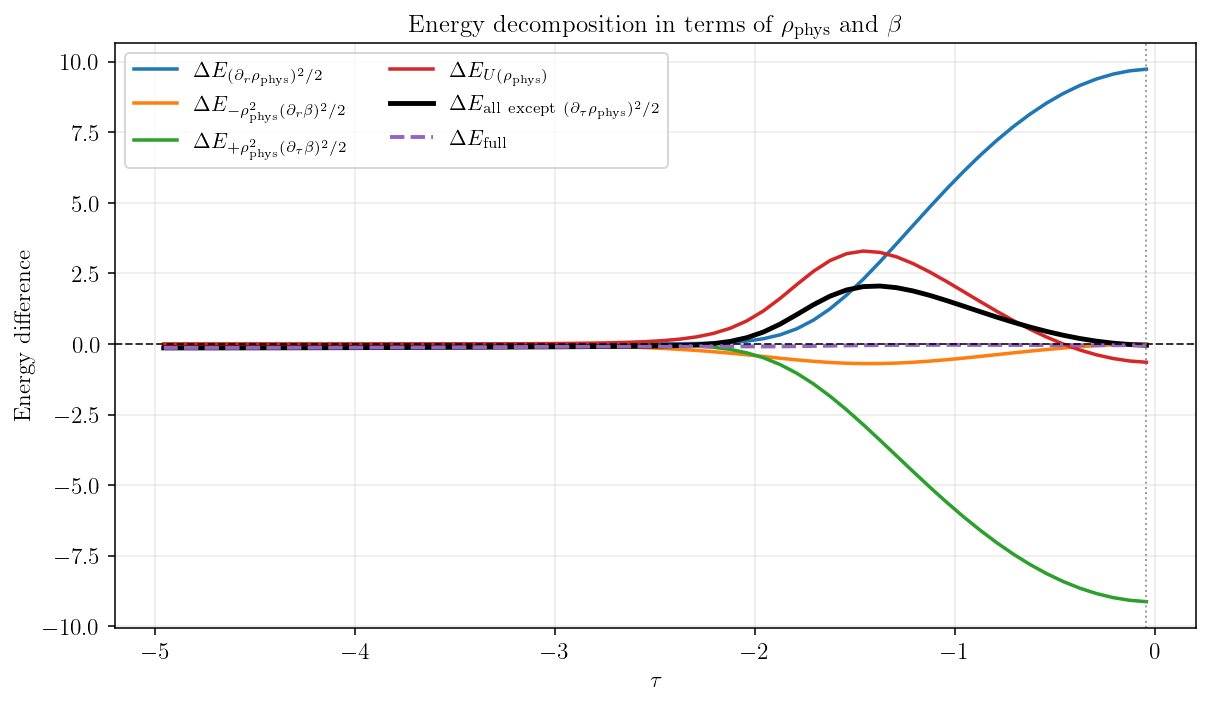

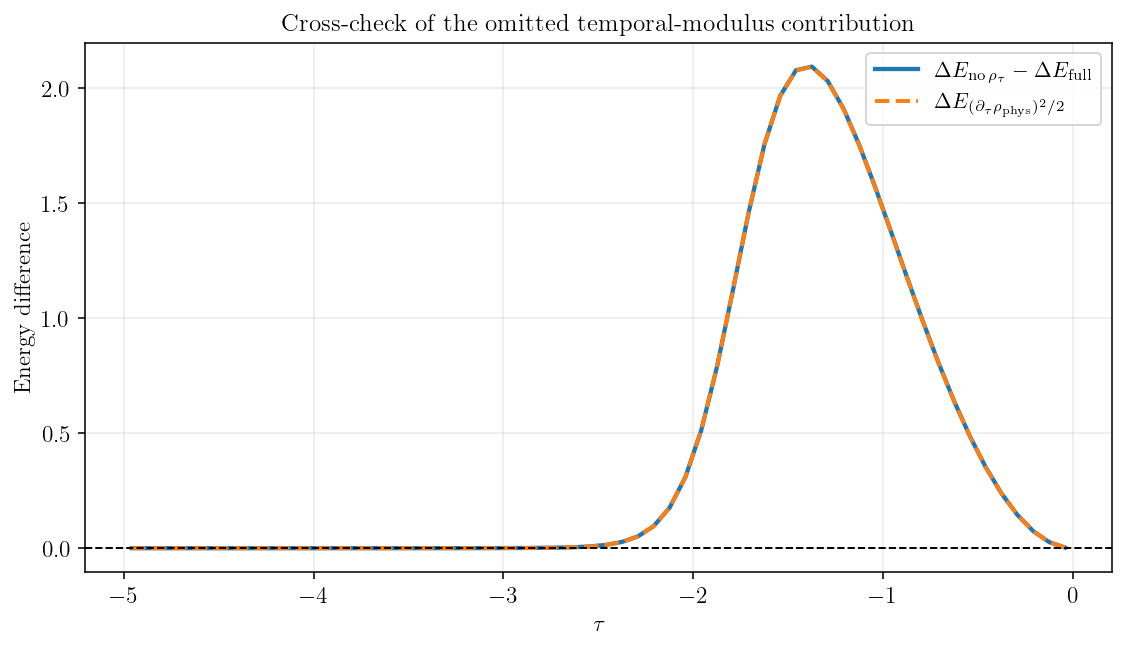

=== Energy decomposition in terms of rho_phys and beta ===
rho_hom_phys                      = 1.0232092799e+00
E_no_rho_tau_hom                  = -5.8870334920e+01
E_full_hom                        = -5.8870334920e+01

max |E_full_direct - E_full_polar| = 1.5160874114e-03

tau(min-grid)                     = -4.9583333333e+00
tau(0-grid)                       = -4.1666666667e-02

Delta E_no_rho_tau(tau_min)       = -1.4031407309e-01
Delta E_no_rho_tau(tau=0)         = -4.4580492469e-02
Delta E_full(tau_min)             = -1.4031409898e-01
Delta E_full(tau=0)               = -4.7550619618e-02
Delta E_rho_tau(tau_min)          = 2.5651736806e-08
Delta E_rho_tau(tau=0)            = 2.9803809886e-03


In [29]:
# ============================================================
# Energy decomposition in terms of rho_phys and beta:
# plot the sum of ALL Minkowski-energy components EXCEPT
# the temporal-modulus piece (1/2) * (d_tau rho_phys)^2.
#
# Definitions:
#   phi    = (rho_phys / sqrt(2)) * exp(+beta)
#   phibar = (rho_phys / sqrt(2)) * exp(-beta)
#
# Then
#   (d_r phi)(d_r phibar)      = 1/2 (d_r rho_phys)^2 - 1/2 rho_phys^2 (d_r beta)^2
#   -(d_tau phi)(d_tau phibar) = -1/2 (d_tau rho_phys)^2 + 1/2 rho_phys^2 (d_tau beta)^2
#
# So the quantity we want is
#
#   E_no_rho_tau(tau)
#     = 4*pi \int dr r^2 [
#           1/2 (d_r rho_phys)^2
#         - 1/2 rho_phys^2 (d_r beta)^2
#         + 1/2 rho_phys^2 (d_tau beta)^2
#         + U(rho_phys)
#       ]
#
# which is the full Minkowski energy with the piece
#   + 1/2 (d_tau rho_phys)^2
# removed.
# ============================================================

import numpy as np
from scipy.integrate import simpson

tau_grid = np.asarray(solver_o4.grid.tau, dtype=float)
r_grid   = np.asarray(solver_o4.grid.r, dtype=float)

y    = np.asarray(sol_o4.y)
ybar = np.asarray(sol_o4.ybar)

Nr, Nt = y.shape
dt = float(getattr(solver_o4, "dt", getattr(solver_o4.grid, "dtau")))
omega = float(solver_o4.omega)
rho0_phi_units = float(solver_o4.rho0)
rho_eps = float(getattr(solver_o4.settings, "rho_eps", 1e-30))

# ------------------------------------------------------------
# Reconstruct phi, phibar
# ------------------------------------------------------------
phi, phibar = solver_o4.phi(y, ybar)

# ------------------------------------------------------------
# BC-aware tau derivatives of phi, phibar
# ------------------------------------------------------------
phi_tau    = np.zeros_like(phi, dtype=np.complex128)
phibar_tau = np.zeros_like(phibar, dtype=np.complex128)

r = r_grid
inv_r = np.zeros_like(r, dtype=float)
inv_r[r != 0.0] = 1.0 / r[r != 0.0]

tau_increases = (tau_grid[1] > tau_grid[0]) if len(tau_grid) >= 2 else True

for i in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver_o4._tau_neighbors(y, ybar, i)

    if tau_increases:
        y_t  = (y_ip1  - y_im1)  / (2.0 * dt)
        yb_t = (yb_ip1 - yb_im1) / (2.0 * dt)
    else:
        y_t  = (y_im1  - y_ip1)  / (2.0 * dt)
        yb_t = (yb_im1 - yb_ip1) / (2.0 * dt)

    y_tot  = y[:, i]    + r * rho0_phi_units
    yb_tot = ybar[:, i] + r * rho0_phi_units

    exp_p = np.exp(+omega * tau_grid[i]) * inv_r
    exp_m = np.exp(-omega * tau_grid[i]) * inv_r

    phi_tau[:, i]    = exp_p * (y_t  + omega * y_tot)
    phibar_tau[:, i] = exp_m * (yb_t - omega * yb_tot)

# ------------------------------------------------------------
# Radial derivatives of phi, phibar
# ------------------------------------------------------------
phi_r    = np.zeros_like(phi, dtype=np.complex128)
phibar_r = np.zeros_like(phibar, dtype=np.complex128)

for i in range(Nt):
    dphi_dr = np.gradient(phi[:, i], r_grid, edge_order=2)
    dphibar_dr = np.gradient(phibar[:, i], r_grid, edge_order=2)
    dphi_dr[0] = 0.0
    dphibar_dr[0] = 0.0
    phi_r[:, i] = dphi_dr
    phibar_r[:, i] = dphibar_dr

# ------------------------------------------------------------
# rho_phys from solver conventions:
#   u = Re(phi phibar) = |phi|^2 in solver units
#   rho_phys = sqrt(2 u)
# ------------------------------------------------------------
u = np.maximum((phi * phibar).real, 0.0)
u_safe = np.maximum(u, 1e-30)

rho_phys = np.sqrt(2.0 * u + rho_eps)
rho_phys_safe = np.maximum(rho_phys, 1e-30)

# ------------------------------------------------------------
# Build beta_r and beta_tau directly from phi, phibar
#
# Since
#   phibar * d_mu phi - phi * d_mu phibar = 2 u * d_mu beta
# and rho_phys^2 = 2u,
# we have equivalently
#   d_mu beta = (phibar*d_mu phi - phi*d_mu phibar) / rho_phys^2
# ------------------------------------------------------------
b_r   = (phibar * phi_r   - phi * phibar_r).real
b_tau = (phibar * phi_tau - phi * phibar_tau).real

beta_r   = b_r   / np.maximum(rho_phys**2, 1e-30)
beta_tau = b_tau / np.maximum(rho_phys**2, 1e-30)

# ------------------------------------------------------------
# Derivatives of rho_phys
# ------------------------------------------------------------
rho_r = np.zeros_like(rho_phys, dtype=float)
for i in range(Nt):
    drho_dr = np.gradient(rho_phys[:, i], r_grid, edge_order=2)
    drho_dr[0] = 0.0
    rho_r[:, i] = drho_dr

rho_tau = np.zeros_like(rho_phys, dtype=float)
for j in range(Nr):
    rho_tau[j, :] = np.gradient(rho_phys[j, :], tau_grid, edge_order=2)

# ------------------------------------------------------------
# Potential term
# ------------------------------------------------------------
U_vals = np.asarray(solver_o4.U(rho_phys), dtype=float)

# ------------------------------------------------------------
# Energy-density pieces in (rho_phys, beta)
# ------------------------------------------------------------
e_rho_r    = 0.5 * rho_r**2
e_beta_r   = -0.5 * rho_phys**2 * beta_r**2
e_beta_tau = +0.5 * rho_phys**2 * beta_tau**2
e_rho_tau  = +0.5 * rho_tau**2
e_pot      = U_vals

# Check:
# full Minkowski density should be
#   e_full = e_rho_r + e_beta_r + e_beta_tau - e_rho_tau + e_pot
# because -(d_tau phi d_tau phibar) = -1/2 rho_tau^2 + 1/2 rho^2 beta_tau^2
e_full_from_polar = e_rho_r + e_beta_r + e_beta_tau - e_rho_tau + e_pot

# Quantity requested:
# sum of all components EXCEPT the temporal-modulus term
e_no_rho_tau = e_rho_r + e_beta_r + e_beta_tau + e_pot

# Direct density from phi, phibar for cross-check
e_direct = -(phi_tau * phibar_tau).real + (phi_r * phibar_r).real + U_vals

# ------------------------------------------------------------
# Integrate over r
# ------------------------------------------------------------
def spherical_integral_over_r(density_2d):
    return np.array(
        [4.0 * np.pi * simpson(r_grid**2 * density_2d[:, i], x=r_grid) for i in range(Nt)],
        dtype=float,
    )

E_rho_r_tau    = spherical_integral_over_r(e_rho_r)
E_beta_r_tau   = spherical_integral_over_r(e_beta_r)
E_beta_tau_tau = spherical_integral_over_r(e_beta_tau)
E_rho_tau_tau  = spherical_integral_over_r(e_rho_tau)
E_pot_tau      = spherical_integral_over_r(e_pot)

E_no_rho_tau_tau    = spherical_integral_over_r(e_no_rho_tau)
E_full_direct_tau   = spherical_integral_over_r(e_direct)
E_full_polar_tau    = spherical_integral_over_r(e_full_from_polar)

# ------------------------------------------------------------
# Homogeneous reference
# In the homogeneous background:
#   rho_phys,h = sqrt(2) rho0
#   beta_r = 0
#   rho_r = 0
#   rho_tau = 0
#   beta_tau = omega
# ------------------------------------------------------------
rho_hom_phys = np.sqrt(2.0) * rho0_phi_units
U_hom = float(np.asarray(solver_o4.U(np.array([rho_hom_phys], dtype=float))).flat[0])

V_space = float((4.0 / 3.0) * np.pi * (r_grid[-1]**3))

E_rho_r_hom    = 0.0
E_beta_r_hom   = 0.0
E_beta_tau_hom = 0.5 * rho_hom_phys**2 * omega**2 * V_space   # = omega^2 rho0^2 V
E_rho_tau_hom  = 0.0
E_pot_hom      = U_hom * V_space

E_no_rho_tau_hom = E_rho_r_hom + E_beta_r_hom + E_beta_tau_hom + E_pot_hom
E_full_hom       = E_no_rho_tau_hom - E_rho_tau_hom

# ------------------------------------------------------------
# Differences w.r.t. homogeneous
# ------------------------------------------------------------
delta_E_rho_r    = E_rho_r_tau    - E_rho_r_hom
delta_E_beta_r   = E_beta_r_tau   - E_beta_r_hom
delta_E_beta_tau = E_beta_tau_tau - E_beta_tau_hom
delta_E_rho_tau  = E_rho_tau_tau  - E_rho_tau_hom
delta_E_pot      = E_pot_tau      - E_pot_hom

delta_E_no_rho_tau = E_no_rho_tau_tau - E_no_rho_tau_hom
delta_E_full       = E_full_direct_tau - E_full_hom

# ------------------------------------------------------------
# Diagnostics indices
# ------------------------------------------------------------
i_tau0 = int(np.argmin(np.abs(tau_grid - 0.0)))
i_taumin = 0 if tau_grid[0] < tau_grid[-1] else Nt - 1

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 5.2))

ax.plot(tau_grid, delta_E_rho_r,    lw=1.8, label=r"$\Delta E_{(\partial_r \rho_{\rm phys})^2/2}$")
ax.plot(tau_grid, delta_E_beta_r,   lw=1.8, label=r"$\Delta E_{-\rho_{\rm phys}^2(\partial_r\beta)^2/2}$")
ax.plot(tau_grid, delta_E_beta_tau, lw=1.8, label=r"$\Delta E_{+\rho_{\rm phys}^2(\partial_\tau\beta)^2/2}$")
ax.plot(tau_grid, delta_E_pot,      lw=1.8, label=r"$\Delta E_{U(\rho_{\rm phys})}$")

ax.plot(
    tau_grid,
    delta_E_no_rho_tau,
    color="k",
    lw=2.5,
    label=r"$\Delta E_{\rm all\ except\ (\partial_\tau \rho_{\rm phys})^2/2}$"
)

ax.plot(
    tau_grid,
    delta_E_full,
    "--",
    lw=2.0,
    label=r"$\Delta E_{\rm full}$"
)

ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)
ax.axvline(tau_grid[i_tau0], color="gray", ls=":", lw=1.0, alpha=0.8)

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"Energy difference")
ax.set_title(r"Energy decomposition in terms of $\rho_{\rm phys}$ and $\beta$")
ax.legend(loc="best", ncol=2)
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_decomposition_rho_phys_beta_except_rho_tau.pdf",
        bbox_inches="tight",
    )

plt.show()

# ------------------------------------------------------------
# Cross-check plot: missing piece should be exactly delta_E_rho_tau
# since E_full = E_no_rho_tau - E_rho_tau
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(
    tau_grid,
    delta_E_no_rho_tau - delta_E_full,
    lw=2.2,
    label=r"$\Delta E_{\rm no\,\rho_\tau} - \Delta E_{\rm full}$"
)
ax.plot(
    tau_grid,
    delta_E_rho_tau,
    "--",
    lw=2.0,
    label=r"$\Delta E_{(\partial_\tau \rho_{\rm phys})^2/2}$"
)
ax.axhline(0.0, color="k", ls="--", lw=1.0)
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"Energy difference")
ax.set_title(r"Cross-check of the omitted temporal-modulus contribution")
ax.legend(loc="best")
fig.tight_layout()

if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_energy_decomposition_crosscheck_rho_tau_piece.pdf",
        bbox_inches="tight",
    )

plt.show()

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
max_full_err = np.max(np.abs(E_full_direct_tau - E_full_polar_tau))

print("=== Energy decomposition in terms of rho_phys and beta ===")
print(f"rho_hom_phys                      = {rho_hom_phys:.10e}")
print(f"E_no_rho_tau_hom                  = {E_no_rho_tau_hom:.10e}")
print(f"E_full_hom                        = {E_full_hom:.10e}")
print()
print(f"max |E_full_direct - E_full_polar| = {max_full_err:.10e}")
print()
print(f"tau(min-grid)                     = {tau_grid[i_taumin]:.10e}")
print(f"tau(0-grid)                       = {tau_grid[i_tau0]:.10e}")
print()
print(f"Delta E_no_rho_tau(tau_min)       = {delta_E_no_rho_tau[i_taumin]:.10e}")
print(f"Delta E_no_rho_tau(tau=0)         = {delta_E_no_rho_tau[i_tau0]:.10e}")
print(f"Delta E_full(tau_min)             = {delta_E_full[i_taumin]:.10e}")
print(f"Delta E_full(tau=0)               = {delta_E_full[i_tau0]:.10e}")
print(f"Delta E_rho_tau(tau_min)          = {delta_E_rho_tau[i_taumin]:.10e}")
print(f"Delta E_rho_tau(tau=0)            = {delta_E_rho_tau[i_tau0]:.10e}")

## 13. Parallel 2D Analyses for O(3), O(1), and Homogeneous Seeds

We now repeat the same full 2D workflow for the remaining seed families:

- build seed,
- visualize seed,
- run Newton + $\eta_0$ scan,
- print diagnostics,
- visualize final 2D solution,
- compare slices to 1D profiles,
- plot $E_{\mathrm{static}}-E_{\mathrm{hom}}$ vs $\tau$.

All cases are processed with the same code path for transparent side-by-side comparison.


In [30]:
def compare_solution_with_1d(r2d: np.ndarray, tau2d: np.ndarray, rho2d: np.ndarray, title: str):
    fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
    ax[0].plot(tau2d, rho2d[0, :], color="k", label=r"2D at $r=0$")
    ax[1].plot(r2d, rho2d[:, 0], color="k", label=r"2D at $\tau=0$")
    for d, style in zip((4, 3, 1), ("--", ":", "-.")):
        b = bounces_fixed["omega_ref"][d]
        ax[0].plot(tau2d, np.interp(np.abs(tau2d), b["r"], b["phi"]), style, label=rf"1D $O({d})$")
        ax[1].plot(r2d, np.interp(r2d, b["r"], b["phi"]), style, label=rf"1D $O({d})$")
    ax[0].set_xlabel(r"$\tau$")
    ax[0].set_ylabel(r"$\rho$")
    ax[0].set_title(rf"{title}: $r=0$ slice")
    ax[0].legend()
    ax[1].set_xlabel(r"$r$")
    ax[1].set_ylabel(r"$\rho$")
    ax[1].set_title(rf"{title}: $\tau=0$ slice")
    ax[1].legend()
    fig.tight_layout()
    return fig


def run_seed_case(seed_type: str, label: str):
    solver = make_solver(eta0=0.0, verbose=True)
    x0, rho_seed = build_seed(solver, seed_type, profiles_for_seeds)
    r = np.asarray(solver.grid.r, dtype=float)
    tau = np.asarray(solver.grid.tau, dtype=float)

    fig_seed, _ = plot_seed_maps(r, tau, rho_seed, title_prefix=label)
    if CFG["save_figures"]:
        fig_seed.savefig(CFG["figures_dir"] / f"seed_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    sol, meta = _eta_scan_match_charge_local(
        solver,
        x0,
        Q_TARGET_2D,
        eta_start=0.0,
        d_eta=0.05,
        max_steps=80,
        tol_q=1e-6,
    )

    summary = summarize_solution(sol)
    print(f"\n[{label}] final diagnostics:")
    for k, v in summary.items():
        print(f"  {k}: {v}")
    print(f"  eta0*: {meta.get('eta0', np.nan)}")

    rho_final = solver.rho_map(sol.y, sol.ybar)
    fig_sol, _ = plot_solution_maps(r, tau, rho_final, title_prefix=label)
    if CFG["save_figures"]:
        fig_sol.savefig(CFG["figures_dir"] / f"solution_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    fig_cmp = compare_solution_with_1d(r, tau, rho_final, title=label)
    if CFG["save_figures"]:
        fig_cmp.savefig(CFG["figures_dir"] / f"comparison_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    static = compute_static_energy_minus_hom_vs_tau(solver, sol.y, sol.ybar)
    fig_st, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.plot(static["tau"], static["delta_E_static"], marker="o", ms=4)
    ax.axhline(0.0, color="k", ls="--", lw=1.2)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$E_{\mathrm{static}}-E_{\mathrm{hom}}$")
    ax.set_title(rf"{label}: static energy diagnostic")
    fig_st.tight_layout()
    if CFG["save_figures"]:
        fig_st.savefig(CFG["figures_dir"] / f"static_energy_{seed_type}.pdf", bbox_inches="tight")
    plt.show()

    return {
        "solver": solver,
        "seed": rho_seed,
        "solution": sol,
        "meta": meta,
        "summary": summary,
        "rho_final": rho_final,
        "static": static,
    }


results_other_seeds = {}


### 13.1 O(3) Static Seed

This seed embeds the 1D $O(3)$ radial profile in $r$ and keeps it constant in $\tau$. It tests whether a spatially symmetric, time-static initialization converges to the same 2D saddle branch as the O(4)-inspired seed.


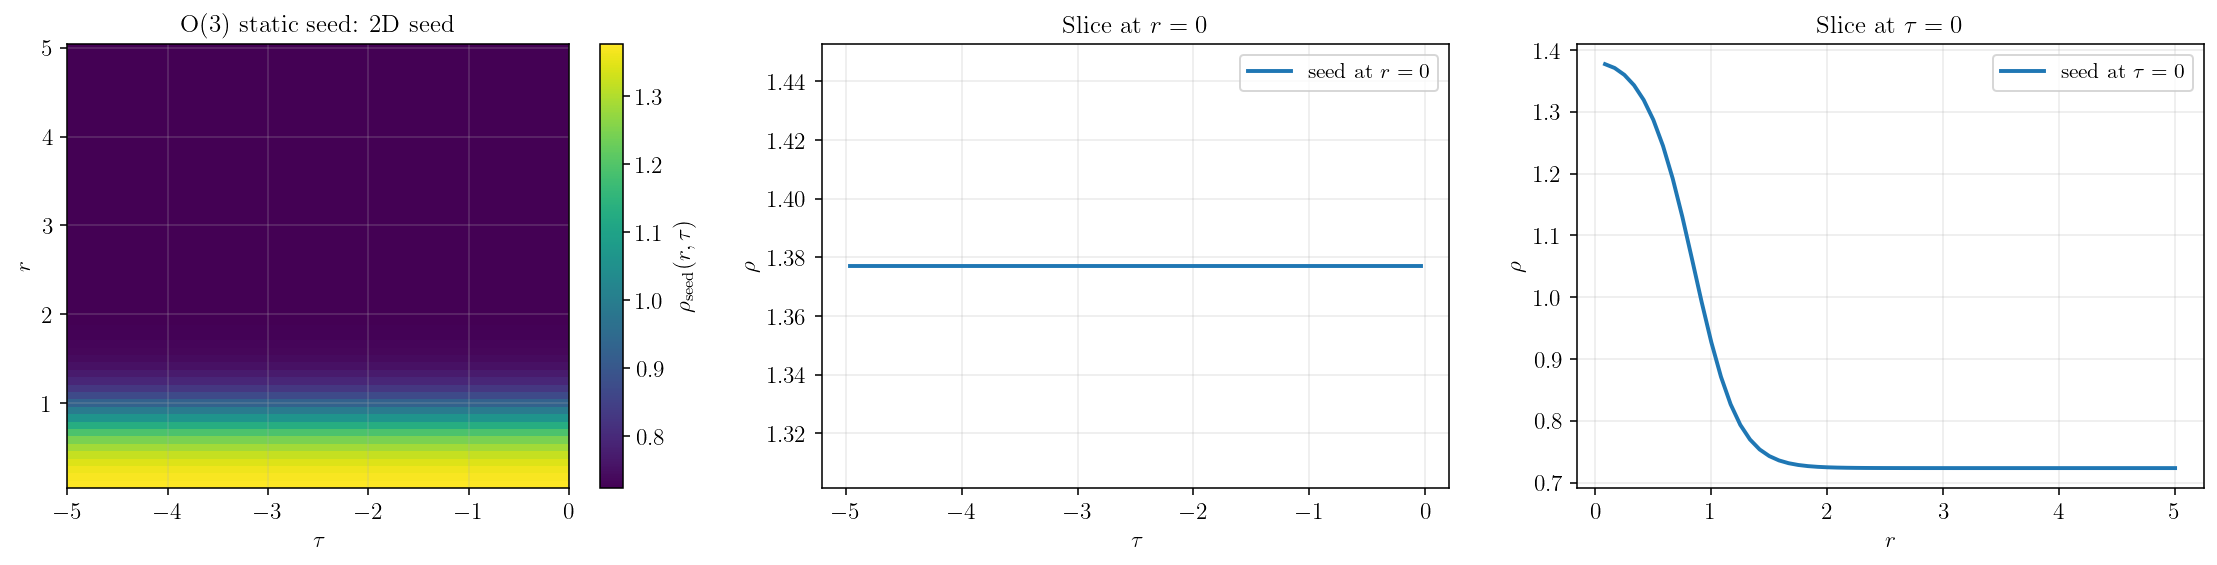

[Targets] eta0 scan references:
  Q_target = 4.65955538e+02
  E_target = 5.88700624e+01
[Newton-compact] iter=01  ||F||=8.005e-01  Q=9.04068200e-01  E=9.58810100e-02  Q/Q*= 1.015900  E/E*= 0.852800
[Newton-compact] iter=02  ||F||=4.371e-03  Q=9.03988500e-01  E=9.59503000e-02  Q/Q*= 1.015800  E/E*= 0.853400
[Newton-compact] iter=03  ||F||=1.299e-06  Q=9.03986800e-01  E=9.59516900e-02  Q/Q*= 1.015800  E/E*= 0.853400
[Newton-compact] iter=04  ||F||=6.313e-13  Q=9.03986800e-01  E=9.59516900e-02  Q/Q*= 1.015800  E/E*= 0.853400
[O4 eta-scan] eta=0.000000  Q=4.73326389e+02  E=5.02401873e+01  Q/Q*= 1.015819  E/E*= 0.853408
[O4 eta-scan] eta=-0.050000  Q=4.70343860e+02  E=5.27683888e+01  Q/Q*= 1.009418  E/E*= 0.896354
[O4 eta-scan] eta=-0.100000  Q=4.67369648e+02  E=5.52746779e+01  Q/Q*= 1.003035  E/E*= 0.938927
[O4 eta-scan] eta=-0.150000  Q=4.64403627e+02  E=5.77592447e+01  Q/Q*= 0.996669  E/E*= 0.981131
[O4 eta-scan*] eta=-0.123821  Q=4.65955538e+02  E=5.64610934e+01  Q/Q*= 1.000000  E/E*= 0

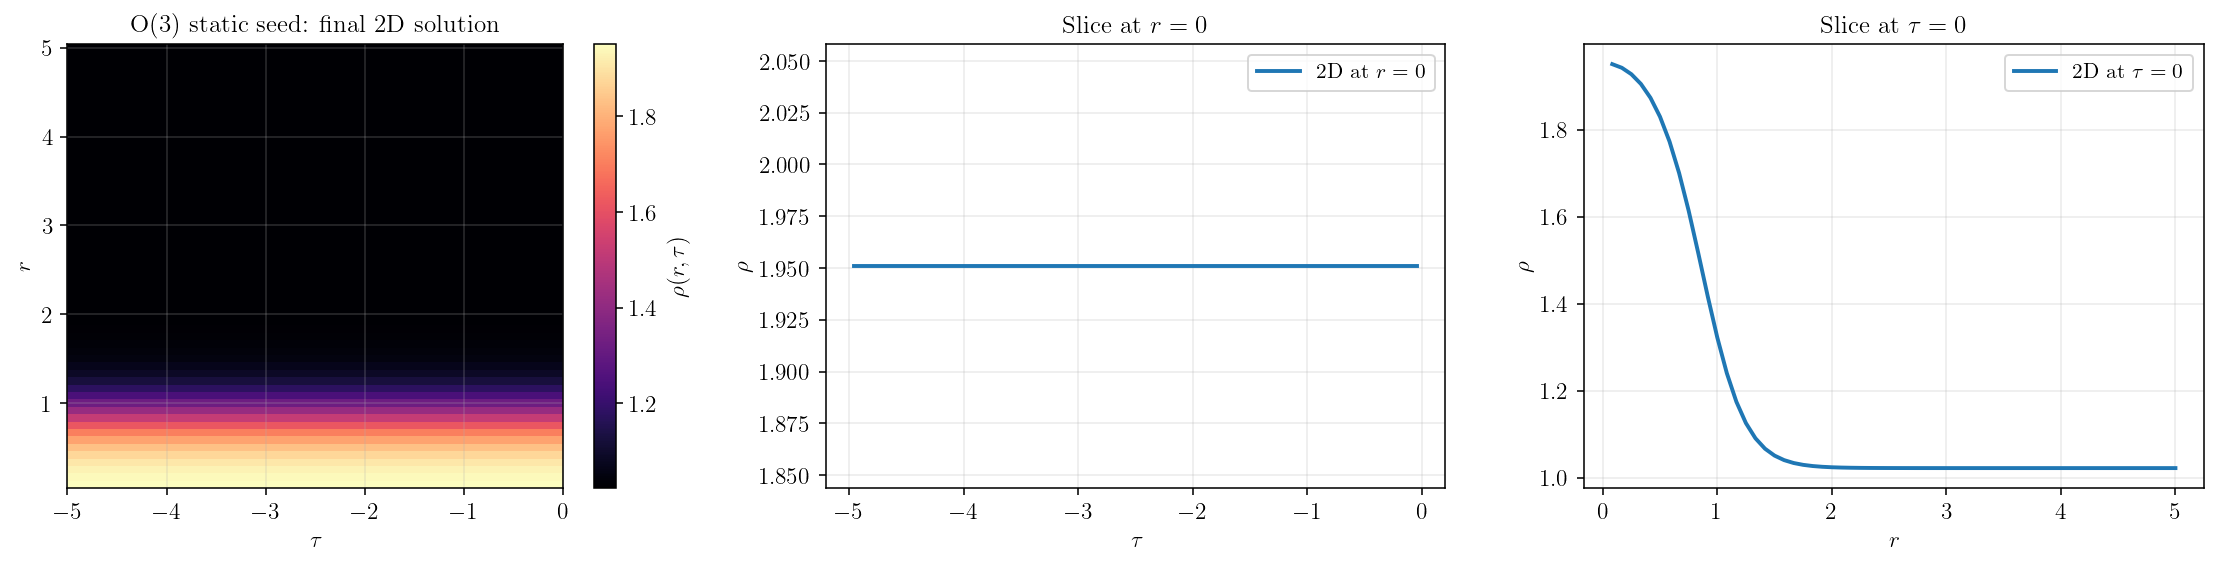

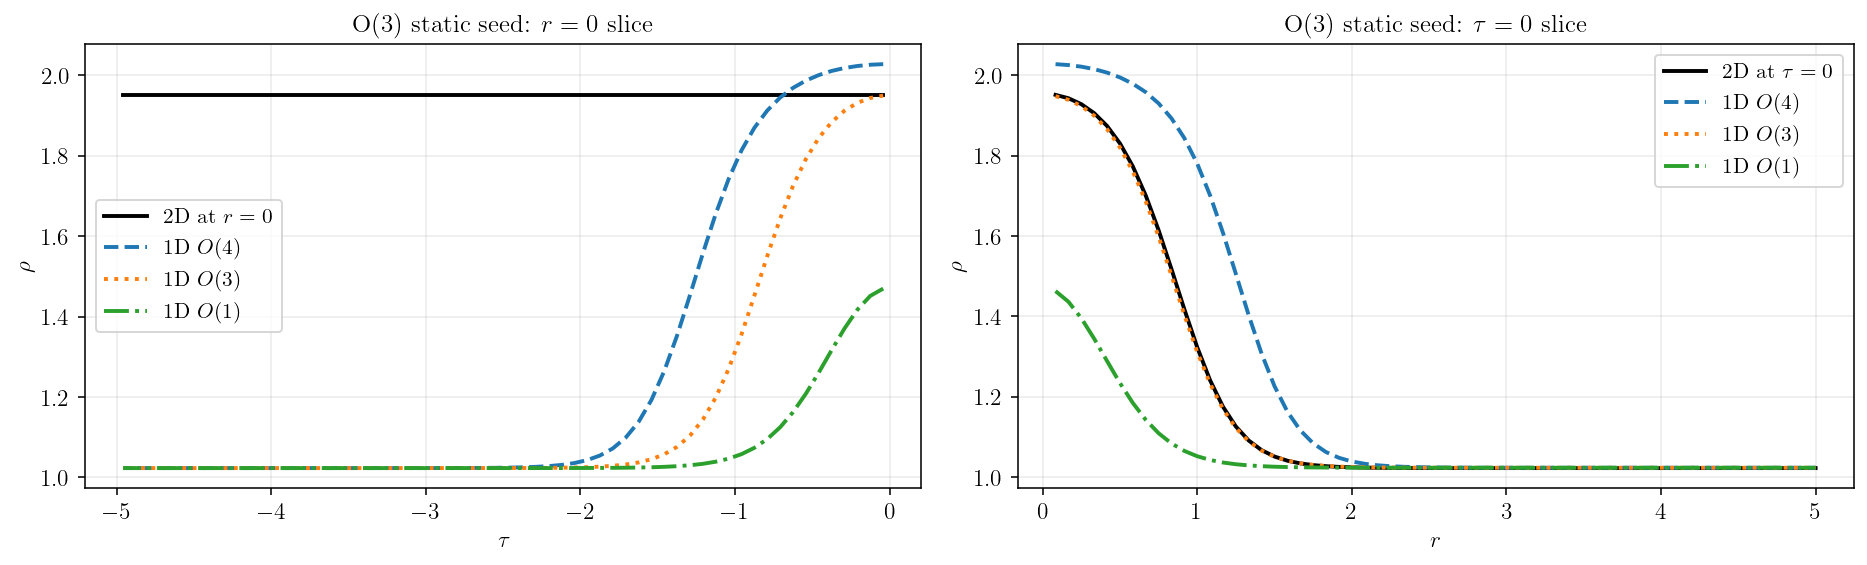

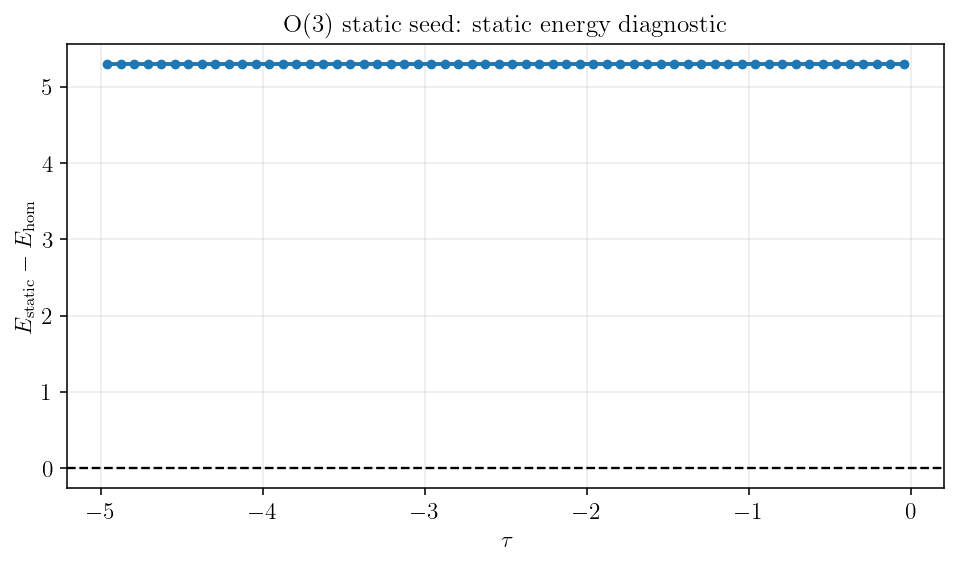

In [31]:
results_other_seeds["O3_static_seed"] = run_seed_case("O3_static_seed", "O(3) static seed")

### 13.2 O(1) Tau Seed

This seed embeds a 1D profile along $|\tau|$ (constant in $r$), probing a strongly time-structured initialization. The same Newton + $\eta_0$ matching workflow is applied for direct comparison.


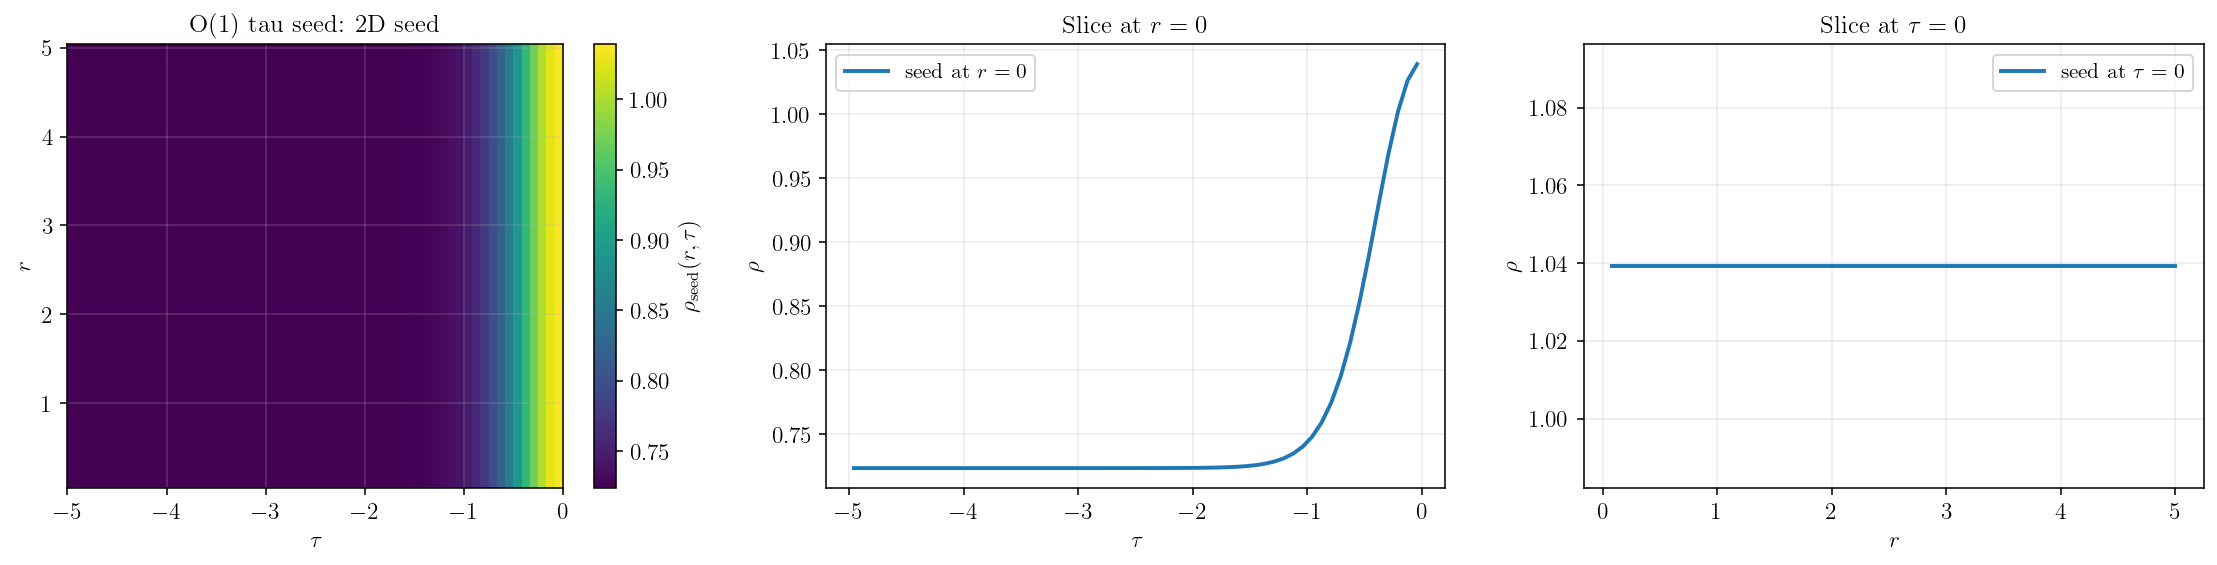

[Targets] eta0 scan references:
  Q_target = 4.65955538e+02
  E_target = 5.88700624e+01
[Newton-compact] iter=01  ||F||=6.116e+01  Q=1.83591800e+00  E=-6.97788000e-01  Q/Q*= 2.063000  E/E*= -6.206200
[Newton-compact] iter=02  ||F||=3.583e+01  Q=1.41145100e+00  E=-2.85127400e-01  Q/Q*= 1.586100  E/E*= -2.536000
[Newton-compact] iter=03  ||F||=1.898e+01  Q=9.43303200e-01  E=6.12460200e-02  Q/Q*= 1.060000  E/E*= 0.544700
[Newton-compact] iter=04  ||F||=2.671e+00  Q=9.71210000e-01  E=3.77852100e-02  Q/Q*= 1.091400  E/E*= 0.336100
[Newton-compact] iter=05  ||F||=9.300e-02  Q=9.64622100e-01  E=4.24562900e-02  Q/Q*= 1.084000  E/E*= 0.377600
[Newton-compact] iter=06  ||F||=1.013e-04  Q=9.64839000e-01  E=4.22495800e-02  Q/Q*= 1.084200  E/E*= 0.375800
[Newton-compact] iter=07  ||F||=1.281e-10  Q=9.64838800e-01  E=4.22497600e-02  Q/Q*= 1.084200  E/E*= 0.375800
[O4 eta-scan] eta=0.000000  Q=5.05188427e+02  E=2.21219210e+01  Q/Q*= 1.084199  E/E*= 0.375775
[O4 eta-scan] eta=-0.050000  Q=5.01841815e+

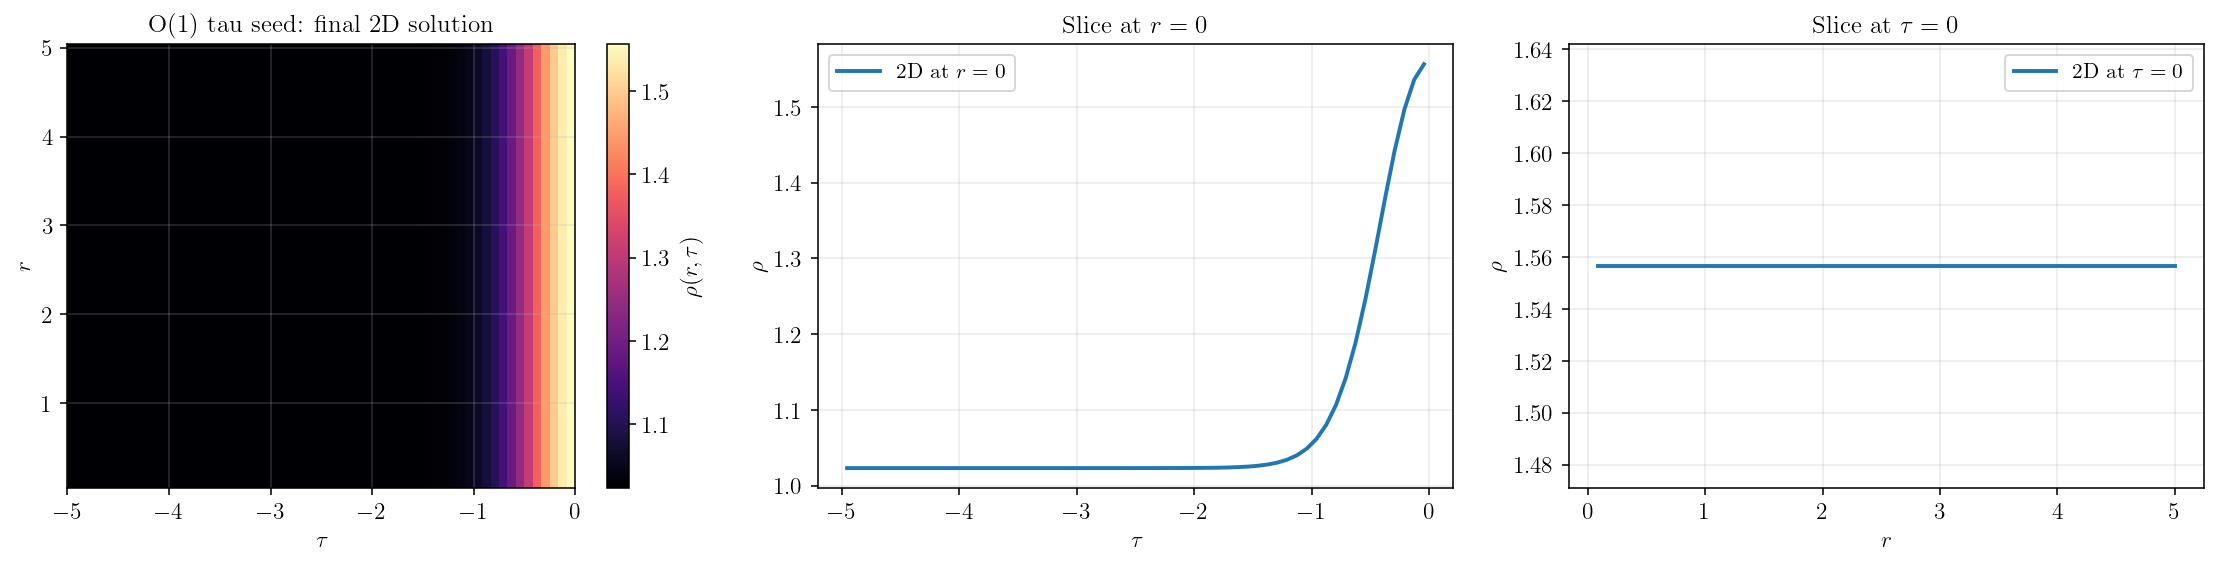

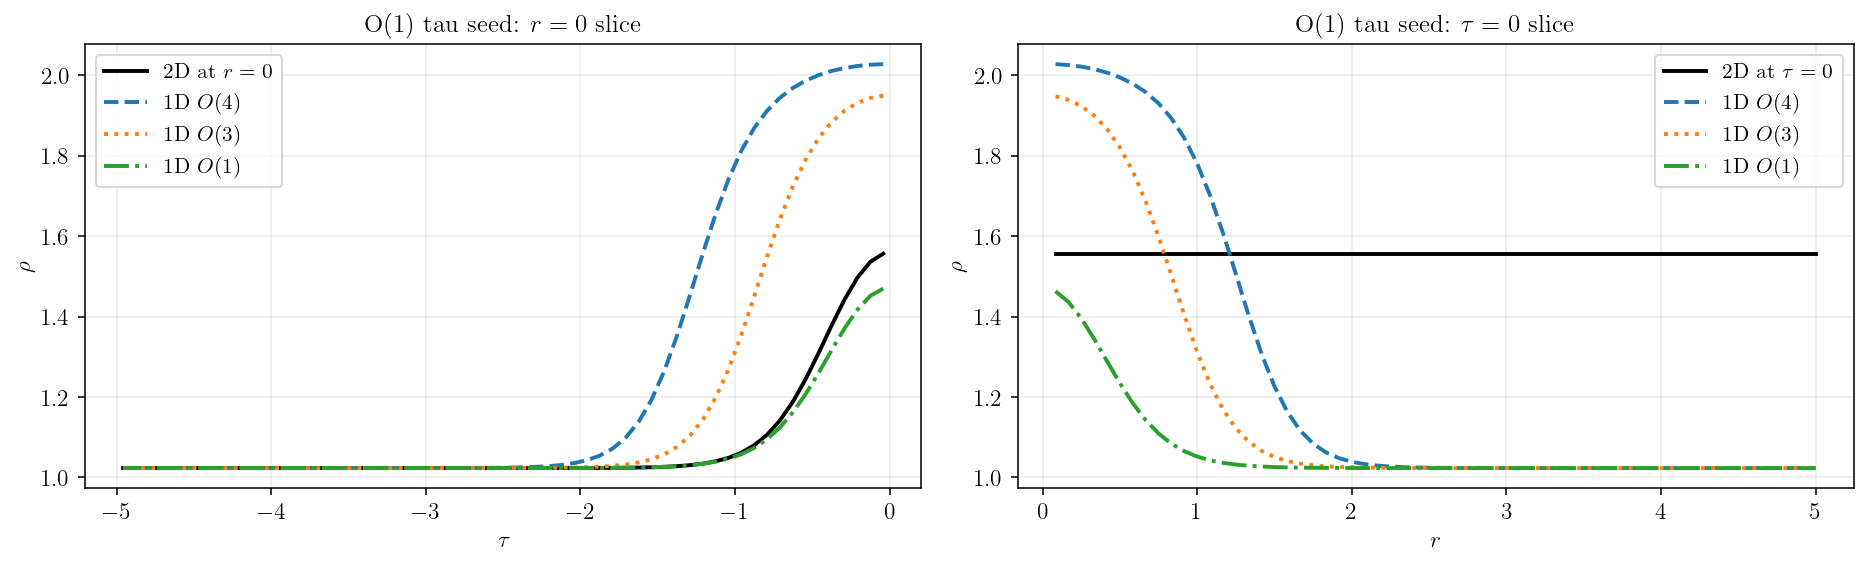

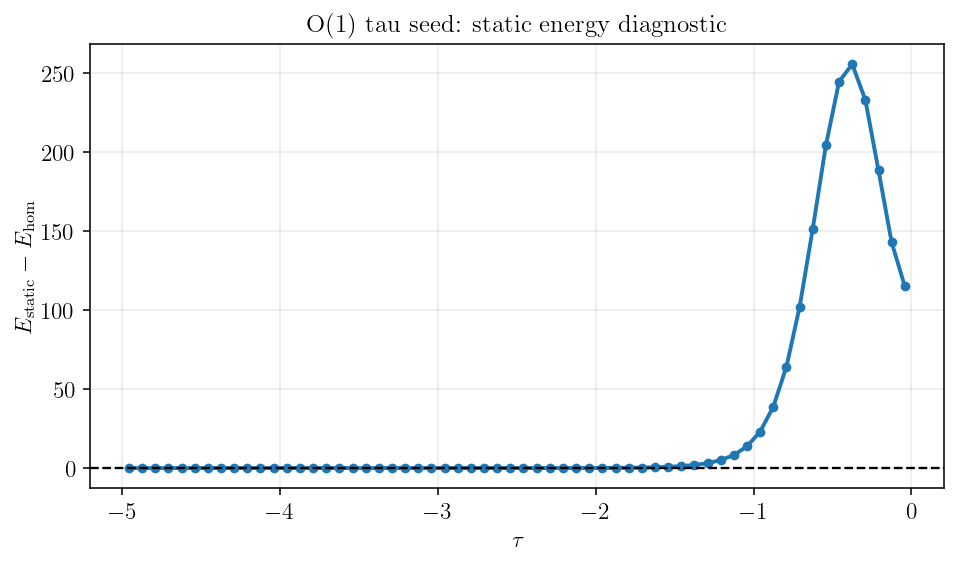

In [32]:
results_other_seeds["O1_tau_seed"] = run_seed_case("O1_tau_seed", "O(1) tau seed")

### 13.3 Homogeneous Seed

This is the trivial false-vacuum seed. Running the same pipeline clarifies whether Newton remains in the homogeneous basin or reaches a nontrivial branch when combined with $\eta_0$ matching.


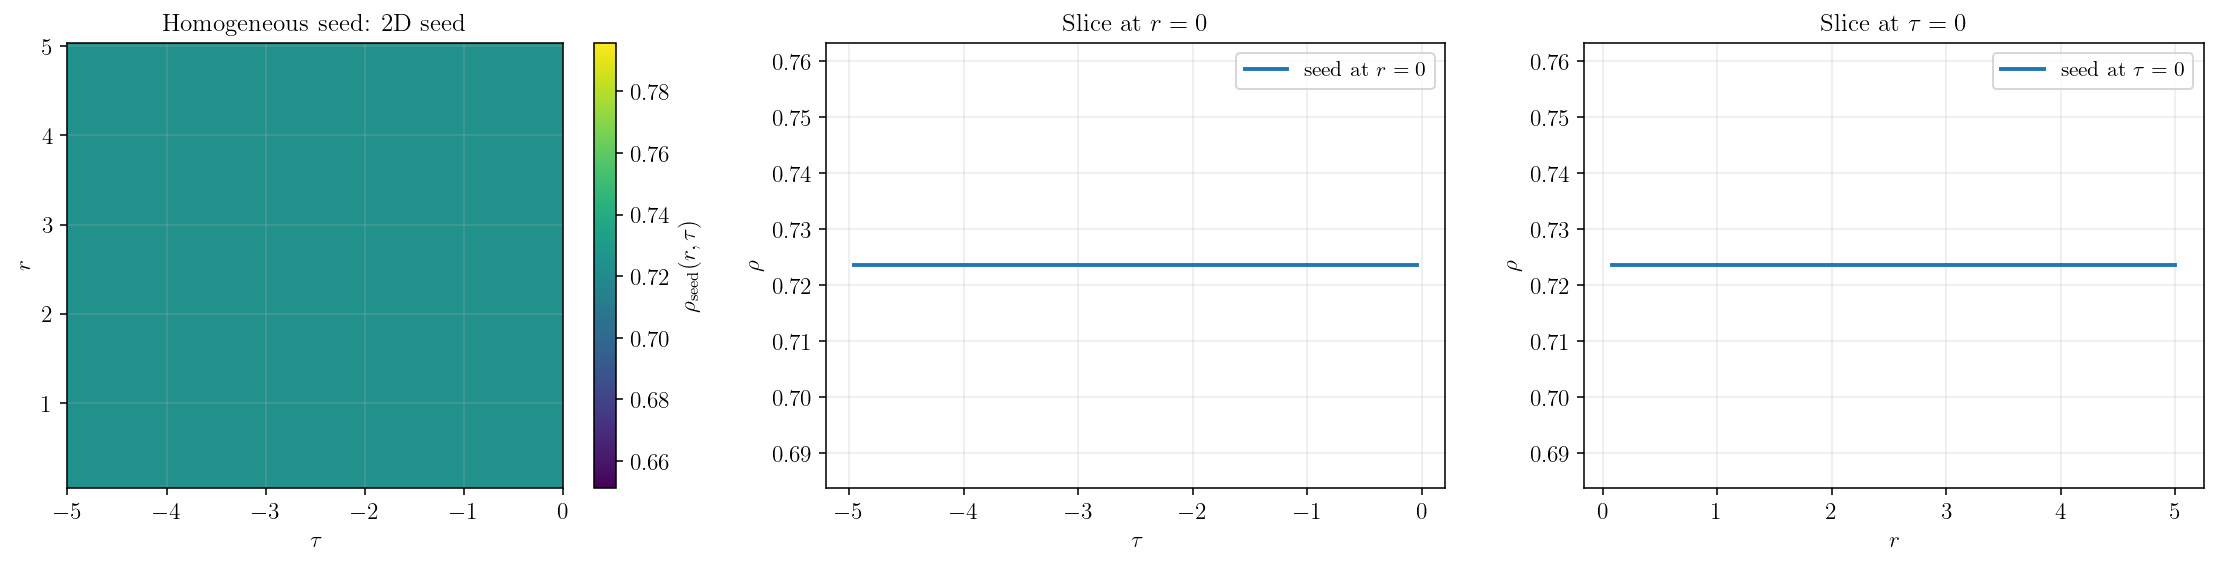

[Targets] eta0 scan references:
  Q_target = 4.65955538e+02
  E_target = 5.88700624e+01
[Newton-compact] iter=01  ||F||=6.973e-13  Q=8.89909500e-01  E=1.12433500e-01  Q/Q*= 1.000000  E/E*= 1.000000
[O4 eta-scan] eta=0.000000  Q=4.65955538e+02  E=5.88700624e+01  Q/Q*= 1.000000  E/E*= 1.000000

[Homogeneous seed] final diagnostics:
  success: 1.0
  iterations: 1.0
  residual_norm: 6.972599593460804e-13
  Q_tau0: 465.9555381714125
  E_tau0: 58.87006237184828
  rho0: 0.7235182203904663
  E_hom: 58.870334919884286
  energy_ratio: 0.9999953703671572
  eta0*: 0.0


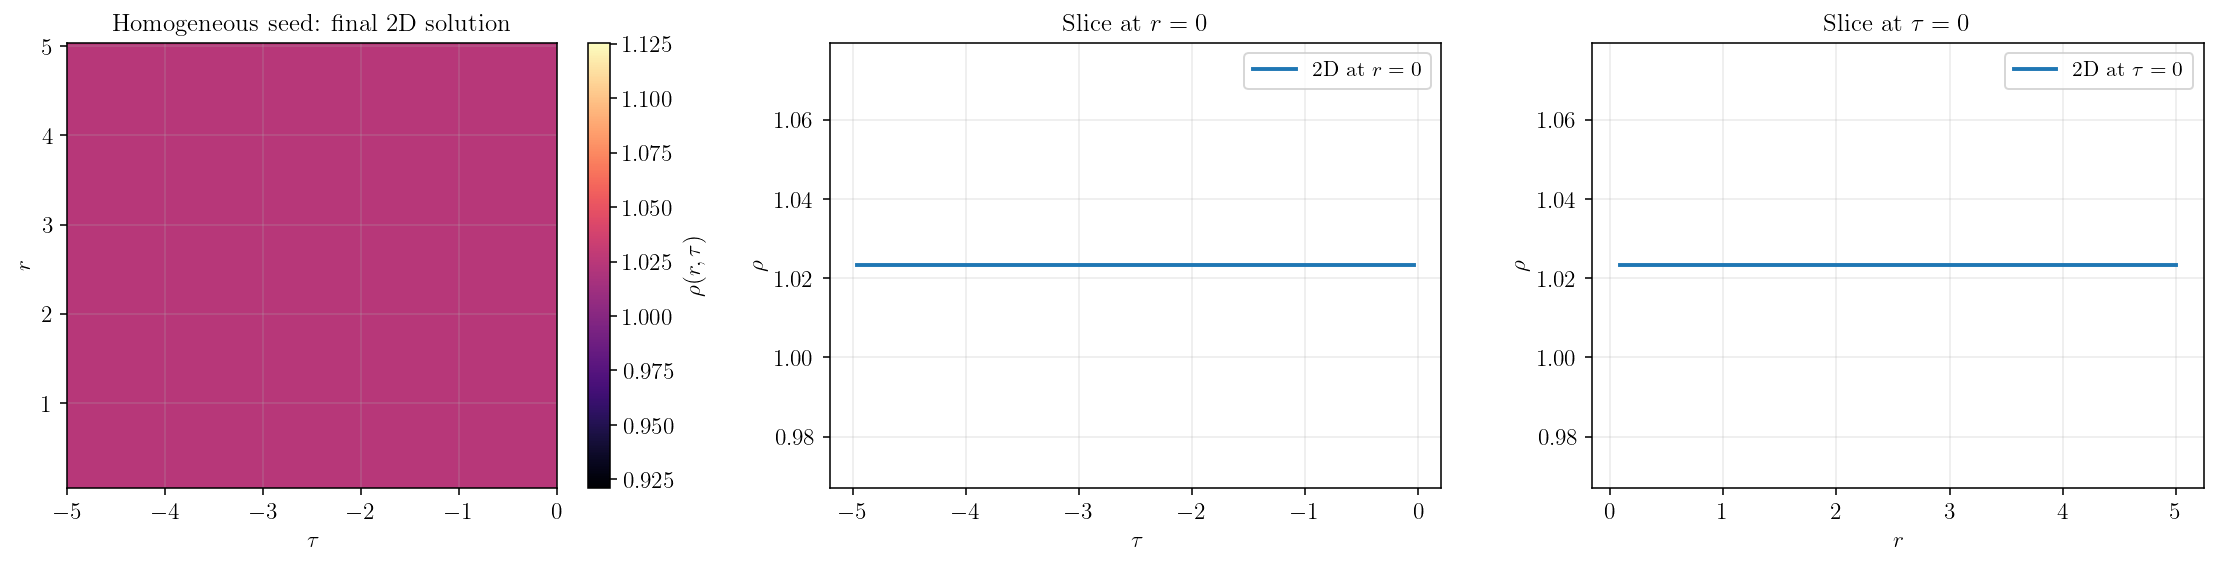

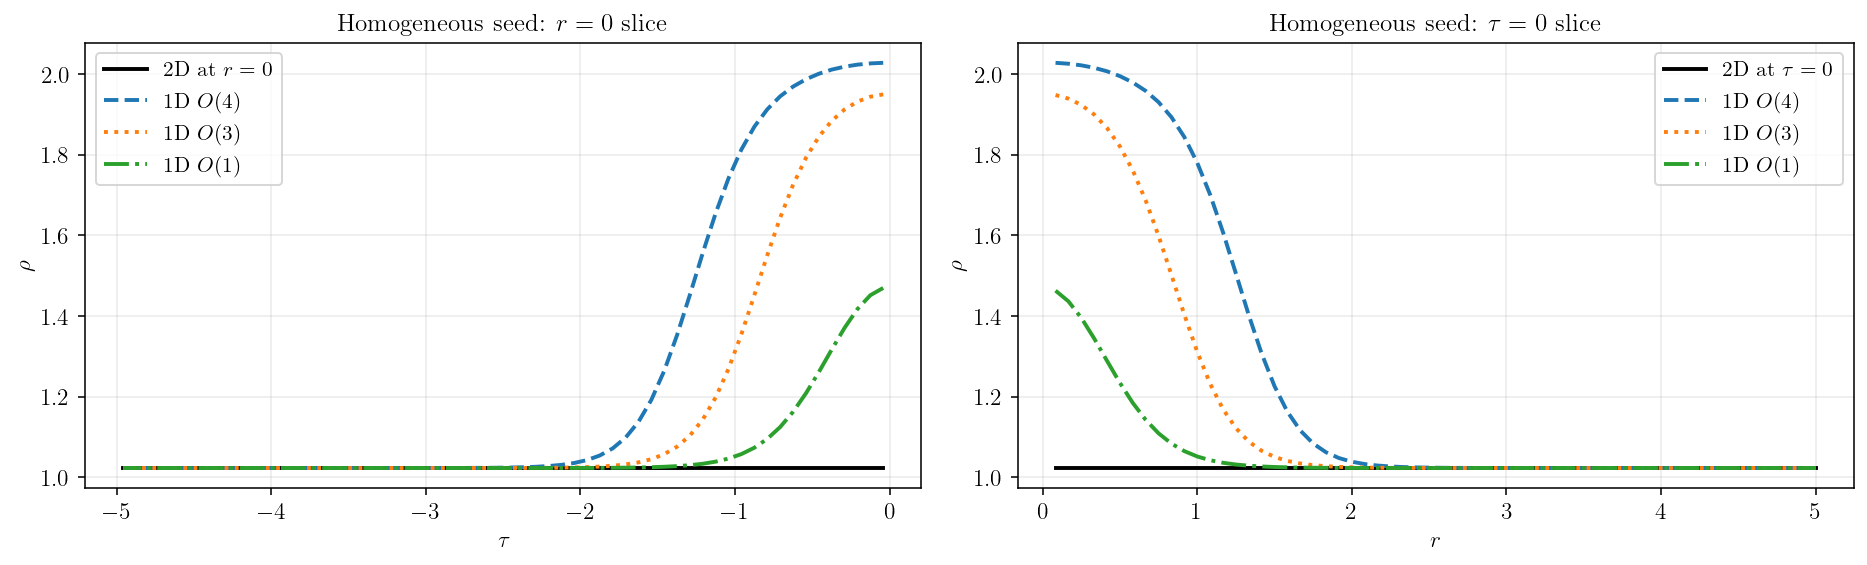

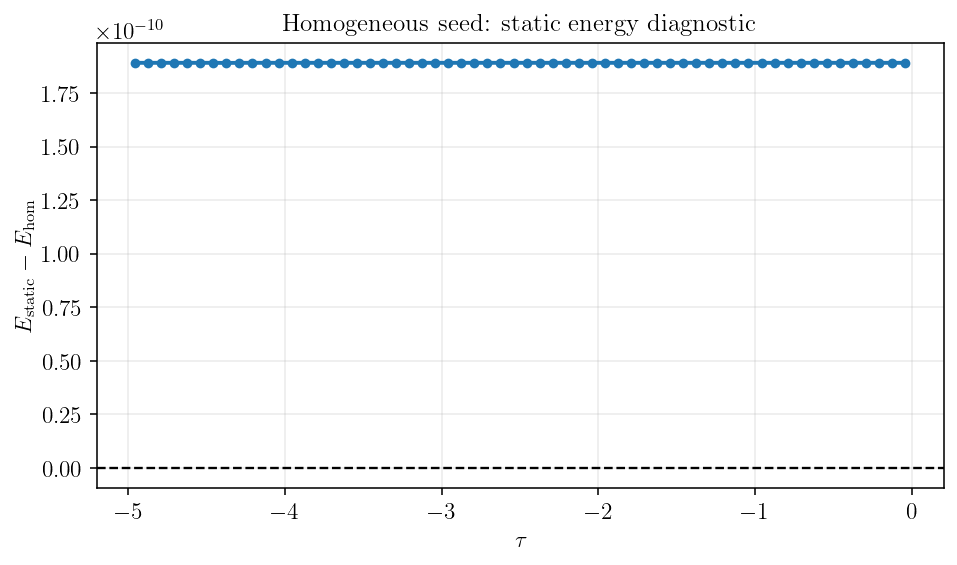

In [33]:
results_other_seeds["homogeneous_seed"] = run_seed_case("homogeneous_seed", "Homogeneous seed")

In [34]:
# Aggregate comparison across all seed families
all_seed_results = {
    "O4_seed": {"summary": summary_o4, "meta": meta_o4, "static": static_o4},
    **{k: {"summary": v["summary"], "meta": v["meta"], "static": v["static"]} for k, v in results_other_seeds.items()},
}

print("Seed-by-seed comparison (final converged quantities)")
print("-" * 88)
print(f"{'seed_type':<20} {'iters':>8} {'residual':>14} {'Q_tau0':>16} {'E_tau0':>16} {'eta0*':>10}")
print("-" * 88)
for seed_name, rec in all_seed_results.items():
    s = rec["summary"]
    eta_star = rec["meta"].get("eta0", np.nan)
    print(f"{seed_name:<20} {int(s['iterations']):>8d} {s['residual_norm']:>14.6e} {s['Q_tau0']:>16.8e} {s['E_tau0']:>16.8e} {eta_star:>10.5f}")


Seed-by-seed comparison (final converged quantities)
----------------------------------------------------------------------------------------
seed_type               iters       residual           Q_tau0           E_tau0      eta0*
----------------------------------------------------------------------------------------
O4_seed                     2   8.015986e-13   4.65955538e+02   5.89386797e+01   -0.08500
O3_static_seed              1   7.840593e-13   4.65955538e+02   5.64610934e+01   -0.12382
O1_tau_seed                 2   2.368674e-12   4.65955538e+02   5.66149287e+01   -0.59449
homogeneous_seed            1   6.972600e-13   4.65955538e+02   5.88700624e+01    0.00000


## 14. Descending Beta Continuation Scan for O(4), O(3), and O(1) Seeds

This section performs a continuation scan in decreasing $\beta$ for the converged 2D solutions obtained from the three nontrivial seed families:

- O(4)-based branch,
- O(3)-static-seed branch,
- O(1)-tau-seed branch.

At each new $\beta$ step, we use the previous converged solution as the initial ansatz (after grid-aware resampling when needed), then run a fresh $\eta_0$ scan to match the same target charge.

Scan rules:

- For O(3) and O(1): uniform descending step $\Delta\beta=0.5$ down to $\beta_{\min}=0.1$.
- For O(4): descending step $\Delta\beta=0.5$ until $\beta=3$, then refined step $\Delta\beta=0.1$ down to $\beta_{\min}=0.1$.

For each point we store and compare key diagnostics, in particular $E/E_{\mathrm{ref}}$, where $E_{\mathrm{ref}}$ is the homogeneous reference energy from `compute_targets_tau0_ghost(...)` at the same solver/grid settings.


In [41]:
beta_start = float(CFG_2D["beta"])
beta_min = 0.1
Q_target_beta_scan = float(Q_TARGET_2D)

# Branch setup from already converged seed solutions
beta_scan_setup = {
    "O4_seed": {
        "label": "O(4) branch",
        "solver0": solver_o4,
        "sol0": sol_o4,
        "eta0_start": float(meta_o4.get("eta0", 0.0)),
    },
    "O3_static_seed": {
        "label": "O(3) branch",
        "solver0": results_other_seeds["O3_static_seed"]["solver"],
        "sol0": results_other_seeds["O3_static_seed"]["solution"],
        "eta0_start": float(results_other_seeds["O3_static_seed"]["meta"].get("eta0", 0.0)),
    },
    "O1_tau_seed": {
        "label": "O(1) branch",
        "solver0": results_other_seeds["O1_tau_seed"]["solver"],
        "sol0": results_other_seeds["O1_tau_seed"]["solution"],
        "eta0_start": float(results_other_seeds["O1_tau_seed"]["meta"].get("eta0", 0.0)),
    },
}

beta_scan_results = {}

for seed_key, cfg in beta_scan_setup.items():
    print(f"\n=== Beta continuation: {cfg['label']} ({seed_key}) ===")

    # Build descending beta list with the requested rule per branch.
    beta_list = [beta_start]
    b = float(beta_start)
    while b > beta_min + 1e-12:
        if seed_key == "O4_seed" and b <= 5.0 + 1e-12:
            db = 0.1
        else:
            db = 0.5
        b_next = max(beta_min, b - db)
        if abs(b_next - beta_list[-1]) < 1e-12:
            break
        beta_list.append(float(np.round(b_next, 10)))
        b = b_next

    prev_solver = cfg["solver0"]
    prev_sol = cfg["sol0"]
    prev_eta = float(cfg["eta0_start"])
    records = []

    # Baseline point at beta_start
    tgt0 = compute_targets_tau0_ghost(prev_solver, subtract_background_charge=False)
    q0 = float(compute_charge_tau0_ghost_2d(prev_solver, prev_sol.y, prev_sol.ybar, subtract_background=False))
    e0 = float(prev_sol.E_tau0)
    qref0 = float(tgt0["Q"])
    eref0 = float(tgt0["E"])
    records.append(
        {
            "beta": float(beta_list[0]),
            "eta0": float(prev_eta),
            "Q": q0,
            "Q_ref": qref0,
            "Q_ratio": q0 / qref0 if abs(qref0) > 1e-30 else np.nan,
            "E": e0,
            "E_ref": eref0,
            "E_ratio": e0 / eref0 if abs(eref0) > 1e-30 else np.nan,
            "residual_norm": float(prev_sol.residual_norm),
            "iterations": float(prev_sol.iterations),
            "solution": prev_sol,
            "solver": prev_solver,
            "status": "ok",
        }
    )
    print(
        f"beta={beta_list[0]:.3f}  eta0={prev_eta:+.5f}  "
        f"Q/Q_ref={records[-1]['Q_ratio']:.6f}  E/E_ref={records[-1]['E_ratio']:.6f}"
    )

    for beta_val in beta_list[1:]:
        settings_new = Bubble2DSettings(
            Nr=CFG_2D["Nr"],
            Ntau=CFG_2D["Ntau"],
            Lr=CFG_2D["Lr"],
            beta=float(beta_val),
            omega_ref=CFG_2D["omega_ref"],
            eta0=float(prev_eta),
            rho0=float(CFG_2D["rho0_false"]),
            newton_tol=CFG_2D["newton_tol"],
            newton_max_iter=CFG_2D["newton_max_iter"],
            damping=CFG_2D["damping"],
            max_backtracks=CFG_2D["max_backtracks"],
            rho0_bracket=CFG_2D["rho0_bracket"],
            complex_saddle=CFG_2D["complex_saddle"],
            verbose=True,
            tau_bc="twisted",
            r_bc="neumann",
            allow_debug_bcs=False,
        )
        solver_new = Bubble2DSolver(settings_new, U, dU, d2U)

        # Continuation seed: use the previous converged state directly whenever possible.
        # This is the most faithful warm-start and avoids introducing interpolation artifacts.
        x_prev = np.asarray(prev_sol.x, dtype=float).copy()
        if x_prev.size == solver_new._zero_vec().size:
            x_seed_new = x_prev
            seed_mode = "direct prev_sol.x"
        else:
            x_seed_new = _resample_seed_to_solver_grid(prev_solver, solver_new, x_prev)
            seed_mode = "resampled prev_sol.x"

        seed_res = float(np.linalg.norm(solver_new.residual(np.asarray(x_seed_new, dtype=float))))

        print(f"\n[{seed_key}] beta={beta_val:.3f}: first Newton + eta scan")
        print(f"[{seed_key}] beta={beta_val:.3f}: seed source = {seed_mode}")
        print(f"[{seed_key}] beta={beta_val:.3f}: seed residual before Newton = {seed_res:.6e}")

        # Kernel-compatibility guard: support both old and new function signatures.
        import inspect
        scan_kwargs = dict(
            Q_target_here=Q_target_beta_scan,
            eta_start=prev_eta,
            d_eta=0.05,
            max_steps=100,
            tol_q=1e-6,
        )
        if "scan_label" in inspect.signature(_eta_scan_match_charge_local).parameters:
            scan_kwargs["scan_label"] = f"{seed_key} eta-scan"

        try:
            sol_new, meta_new = _eta_scan_match_charge_local(
                solver_new,
                x_seed_new,
                **scan_kwargs,
            )

            eta_star = float(meta_new.get("eta0", np.nan))
            solver_new.settings.eta0 = eta_star
            solver_new.eta0 = eta_star

            tgt = compute_targets_tau0_ghost(solver_new, subtract_background_charge=False)
            q_val = float(compute_charge_tau0_ghost_2d(solver_new, sol_new.y, sol_new.ybar, subtract_background=False))
            e_val = float(sol_new.E_tau0)
            q_ref = float(tgt["Q"])
            e_ref = float(tgt["E"])

            rec = {
                "beta": float(beta_val),
                "eta0": eta_star,
                "Q": q_val,
                "Q_ref": q_ref,
                "Q_ratio": q_val / q_ref if abs(q_ref) > 1e-30 else np.nan,
                "E": e_val,
                "E_ref": e_ref,
                "E_ratio": e_val / e_ref if abs(e_ref) > 1e-30 else np.nan,
                "residual_norm": float(sol_new.residual_norm),
                "iterations": float(sol_new.iterations),
                "solution": sol_new,
                "solver": solver_new,
                "meta": meta_new,
                "status": "ok",
            }
            records.append(rec)

            print(
                f"[{seed_key}] beta={beta_val:.3f}  eta0={eta_star:+.5f}  "
                f"Q/Q_ref={rec['Q_ratio']:.6f}  E/E_ref={rec['E_ratio']:.6f}"
            )

            prev_solver = solver_new
            prev_sol = sol_new
            prev_eta = eta_star

        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[{seed_key}] beta={beta_val:.3f} failed -> {msg}")
            records.append(
                {
                    "beta": float(beta_val),
                    "eta0": np.nan,
                    "Q": np.nan,
                    "Q_ref": np.nan,
                    "Q_ratio": np.nan,
                    "E": np.nan,
                    "E_ref": np.nan,
                    "E_ratio": np.nan,
                    "residual_norm": np.nan,
                    "iterations": np.nan,
                    "solution": None,
                    "solver": solver_new,
                    "meta": None,
                    "status": "failed",
                    "error": msg,
                }
            )
            continue

    beta_scan_results[seed_key] = {
        "label": cfg["label"],
        "records": records,
    }


# Compact summary table
print("\nBeta continuation summary (key quantities)")
print("-" * 124)
print(f"{'seed':<18} {'beta':>8} {'eta0*':>10} {'Q/Q_ref':>12} {'E/E_ref':>12} {'residual':>14} {'iters':>8} {'status':>10}")
print("-" * 124)
for seed_key, out in beta_scan_results.items():
    for rec in out["records"]:
        status = rec.get("status", "ok")
        eta_str = f"{rec['eta0']:>10.5f}" if np.isfinite(rec.get("eta0", np.nan)) else f"{'nan':>10}"
        qratio_str = f"{rec['Q_ratio']:>12.6f}" if np.isfinite(rec.get("Q_ratio", np.nan)) else f"{'nan':>12}"
        eratio_str = f"{rec['E_ratio']:>12.6f}" if np.isfinite(rec.get("E_ratio", np.nan)) else f"{'nan':>12}"
        res_str = f"{rec['residual_norm']:>14.6e}" if np.isfinite(rec.get("residual_norm", np.nan)) else f"{'nan':>14}"
        it_str = f"{int(rec['iterations']):>8d}" if np.isfinite(rec.get("iterations", np.nan)) else f"{'nan':>8}"
        print(
            f"{seed_key:<18} {rec['beta']:>8.3f} {eta_str} {qratio_str} {eratio_str} {res_str} {it_str} {status:>10}"
        )



=== Beta continuation: O(4) branch (O4_seed) ===
beta=10.000  eta0=-0.08500  Q/Q_ref=1.000000  E/E_ref=1.001166

[O4_seed] beta=9.500: first Newton + eta scan
[O4_seed] beta=9.500: seed source = direct prev_sol.x
[O4_seed] beta=9.500: seed residual before Newton = 1.725938e+00
[Targets] eta0 scan references:
  Q_target = 4.65955538e+02
  E_target = 5.88700624e+01


[Newton-compact] iter=01  ||F||=1.726e+00  Q=8.87382800e-01  E=1.14397000e-01  Q/Q*= 0.997200  E/E*= 1.017500
[Newton-compact] iter=02  ||F||=7.746e-01  Q=8.89940200e-01  E=1.12709600e-01  Q/Q*= 1.000000  E/E*= 1.002500
[Newton-compact] iter=03  ||F||=2.678e-02  Q=8.89887500e-01  E=1.12580400e-01  Q/Q*= 1.000000  E/E*= 1.001300
[Newton-compact] iter=04  ||F||=3.495e-05  Q=8.89887400e-01  E=1.12577900e-01  Q/Q*= 1.000000  E/E*= 1.001300
[Newton-compact] iter=05  ||F||=1.974e-10  Q=8.89887400e-01  E=1.12577900e-01  Q/Q*= 1.000000  E/E*= 1.001300
[O4 eta-scan] eta=-0.084997  Q=4.65943977e+02  E=5.89456621e+01  Q/Q*= 0.999975  E/E*= 1.001284
[O4 eta-scan] eta=-0.034997  Q=4.69073903e+02  E=5.62759685e+01  Q/Q*= 1.006692  E/E*= 0.955935
[O4 eta-scan*] eta=-0.084812  Q=4.65955538e+02  E=5.89358304e+01  Q/Q*= 1.000000  E/E*= 1.001117
[O4_seed] beta=9.500  eta0=-0.08481  Q/Q_ref=1.000000  E/E_ref=1.001117

[O4_seed] beta=9.000: first Newton + eta scan
[O4_seed] beta=9.000: seed source = direct

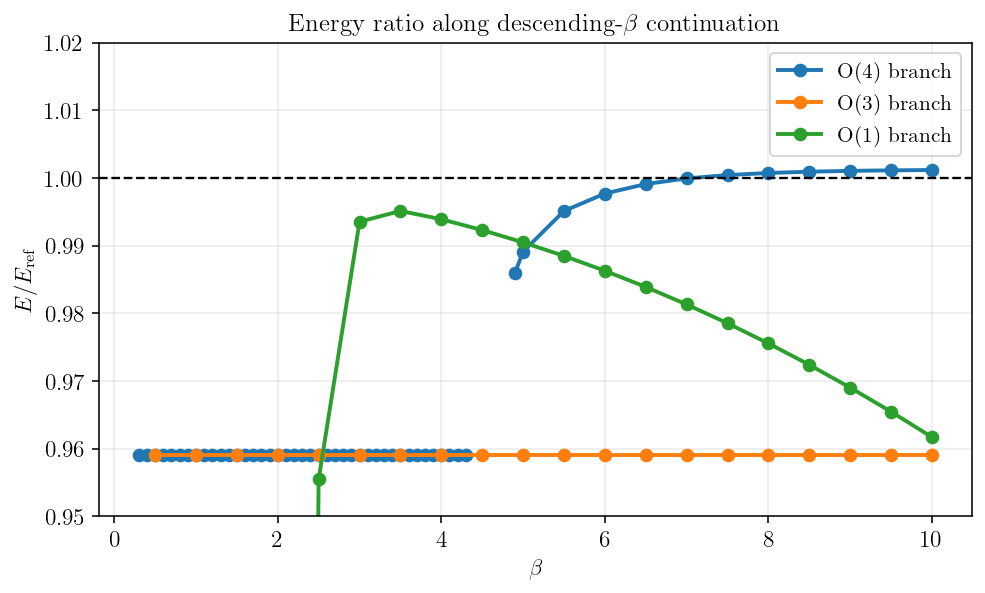

In [45]:
# Plot: E/E_ref vs beta
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for seed_key, out in beta_scan_results.items():
    recs = out["records"]
    bet = np.array([r["beta"] for r in recs], dtype=float)
    er = np.array([r["E_ratio"] for r in recs], dtype=float)

    order = np.argsort(bet)
    bet_s = bet[order]
    er_s = er[order]

    ax.plot(bet_s, er_s, "o-", label=out["label"])

ax.axhline(1.0, color="k", ls="--", lw=1.2)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$E/E_{\mathrm{ref}}$")
ax.set_ylim(0.95, 1.02)
ax.set_title(r"Energy ratio along descending-$\beta$ continuation")
ax.legend(loc="best")

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "beta_continuation_energy_ratios.pdf", bbox_inches="tight")
plt.show()

## 15. O(4) Branch Omega Scan with Eta Matching

We now scan in $\omega$ for the O(4) branch only, starting from $\omega=0.05$ and increasing with step $\Delta\omega=0.05$ up to the maximal available value from the previous 1D scan.

At each $\omega$ step:

- we build a new 2D solver at the same grid and fixed $\beta$,
- at the first step we construct the O(4) seed from the 1D O(4) profile,
- at subsequent steps we use the previous converged 2D solution as continuation seed,
- we run a full $\eta_0$ scan to match the target charge for that step (with verbose Newton-first-step diagnostics).

We store all relevant quantities, in particular the decay suppression exponent, and then plot it as a function of:

- $\omega$,
- $Q/Q_{\max}$ (using the scan maximum as normalization).


In [65]:
from Bubble_finder.rate_exponent import (
    make_V_of_s_from_U,
    compute_euclidean_action_full,
    compute_homogeneous_action,
    compute_suppression_exponent_bubble,
    volume_from_grid,
)

omega_start_scan_o4 = 0.05
omega_step_scan_o4 = 0.05

# Infer omega max from the previous 1D scan (fallback: OMEGA_REF)
omega_max_candidates = []
if "scan_summary_corr" in globals() and 3 in scan_summary_corr and len(scan_summary_corr[3]) > 0:
    omega_max_candidates.append(max(float(r["omega"]) for r in scan_summary_corr[3]))
if "scan_summary" in globals() and 3 in scan_summary and len(scan_summary[3]) > 0:
    omega_max_candidates.append(max(float(r["omega"]) for r in scan_summary[3]))
if "scan_profiles" in globals() and 3 in scan_profiles and len(scan_profiles[3]) > 0:
    omega_max_candidates.append(max(float(r["omega"]) for r in scan_profiles[3]))
omega_max_scan_o4 = float(max(omega_max_candidates)) if len(omega_max_candidates) > 0 else float(OMEGA_REF)

omega_values_o4 = list(np.round(np.arange(omega_start_scan_o4, omega_max_scan_o4 + 1e-12, omega_step_scan_o4), 10))
omega_values_o4 = [float(w) for w in omega_values_o4 if w <= omega_max_scan_o4 + 1e-12]

beta_fixed_o4_scan = float(CFG_2D["beta"])
V_of_s_for_rate = make_V_of_s_from_U(U)

omega_scan_o4_results = []
prev_solver_om = None
prev_sol_om = None
prev_eta_om = 0.0

print(f"O(4) omega scan: omega in [{omega_values_o4[0]:.3f}, {omega_values_o4[-1]:.3f}] with step={omega_step_scan_o4:.3f}")
print(f"Fixed beta for this scan: beta={beta_fixed_o4_scan:.3f}")

for i_om, omega_now in enumerate(omega_values_o4):
    print("\n" + "=" * 88)
    print(f"[O4 omega-scan] step {i_om+1}/{len(omega_values_o4)}  omega={omega_now:.3f}")

    try:
        phi_false_now, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(omega_now), verbose=False)
        rho0_now = float(phi_false_now / np.sqrt(2.0))

        settings_now = Bubble2DSettings(
            Nr=CFG_2D["Nr"],
            Ntau=CFG_2D["Ntau"],
            Lr=CFG_2D["Lr"],
            beta=beta_fixed_o4_scan,
            omega_ref=float(omega_now),
            eta0=float(prev_eta_om if i_om > 0 else 0.0),
            rho0=rho0_now,
            newton_tol=CFG_2D["newton_tol"],
            newton_max_iter=CFG_2D["newton_max_iter"],
            damping=CFG_2D["damping"],
            max_backtracks=CFG_2D["max_backtracks"],
            rho0_bracket=CFG_2D["rho0_bracket"],
            complex_saddle=CFG_2D["complex_saddle"],
            verbose=True,
            tau_bc="twisted",
            r_bc="neumann",
            allow_debug_bcs=False,
        )
        solver_now = Bubble2DSolver(settings_now, U, dU, d2U)

        # Target charge for this omega (same convention used in the scan diagnostics)
        targets_now = compute_targets_tau0_ghost(solver_now, subtract_background_charge=False)
        Q_target_now = float(targets_now["Q"])
        E_ref_now = float(targets_now["E"])

        if i_om == 0:
            bounce_o4_now = solve_or_load_bounce_1d(
                CFG["cache_1d_dir"],
                MODEL,
                omega=float(omega_now),
                d=4,
                rmax=260.0,
                n_grid_points=1000,
                max_iter=180,
                verbose=False,
            )
            x_seed_now, _ = build_seed(solver_now, "O4_seed", {"O4": bounce_o4_now})
            seed_source = "fresh O4 seed from 1D profile"
        else:
            x_prev = np.asarray(prev_sol_om.x, dtype=float).copy()
            if x_prev.size == solver_now._zero_vec().size:
                x_seed_now = x_prev
                seed_source = "direct previous 2D solution"
            else:
                x_seed_now = _resample_seed_to_solver_grid(prev_solver_om, solver_now, x_prev)
                seed_source = "resampled previous 2D solution"

        seed_res_now = float(np.linalg.norm(solver_now.residual(np.asarray(x_seed_now, dtype=float))))
        print(f"[O4 omega-scan] seed source: {seed_source}")
        print(f"[O4 omega-scan] seed residual before Newton = {seed_res_now:.6e}")

        sol_now, meta_now = _eta_scan_match_charge_local(
            solver_now,
            x_seed_now,
            Q_target_here=Q_target_now,
            eta_start=float(prev_eta_om if i_om > 0 else 0.0),
            d_eta=0.05,
            max_steps=100,
            tol_q=1e-6,
            scan_label=f"O4 omega-scan @ omega={omega_now:.2f}",
        )

        eta_star_now = float(meta_now.get("eta0", np.nan))
        solver_now.settings.eta0 = eta_star_now
        solver_now.eta0 = eta_star_now

        Q_now = float(compute_charge_tau0_ghost_2d(solver_now, sol_now.y, sol_now.ybar, subtract_background=False))
        E_now = float(sol_now.E_tau0)

        S_bounce_full_now = float(
            compute_euclidean_action_full(
                sol_now.y,
                sol_now.ybar,
                solver_now.grid,
                omega=float(solver_now.omega),
                eta0=float(solver_now.eta0),
                rho0=float(solver_now.rho0),
                V_of_s=V_of_s_for_rate,
            )
        )
        V_ball_now = float(volume_from_grid(solver_now.grid))
        S_hom_now = float(
            compute_homogeneous_action(
                beta=float(solver_now.settings.beta),
                V_ball=V_ball_now,
                omega=float(solver_now.omega),
                rho0=float(solver_now.rho0),
                V_of_s=V_of_s_for_rate,
            )
        )
        F_decay_now = float(
            compute_suppression_exponent_bubble(
                S_bounce_full=S_bounce_full_now,
                S_hom=S_hom_now,
                eta0=float(solver_now.eta0),
                Q=float(Q_now),
            )
        )

        rho_Q_now = float(Q_now / max(V_ball_now, 1e-30))

        rec = {
            "status": "ok",
            "omega": float(omega_now),
            "beta": float(solver_now.settings.beta),
            "eta0": float(eta_star_now),
            "Q": float(Q_now),
            "Q_target": float(Q_target_now),
            "Q_ratio": float(Q_now / Q_target_now) if abs(Q_target_now) > 1e-30 else np.nan,
            "E": float(E_now),
            "E_ref": float(E_ref_now),
            "E_ratio": float(E_now / E_ref_now) if abs(E_ref_now) > 1e-30 else np.nan,
            "rho_Q": float(rho_Q_now),
            "S_bounce_full": float(S_bounce_full_now),
            "S_hom": float(S_hom_now),
            "F_decay": float(F_decay_now),
            "residual_norm": float(sol_now.residual_norm),
            "iterations": float(sol_now.iterations),
            "solver": solver_now,
            "solution": sol_now,
            "meta": meta_now,
        }
        omega_scan_o4_results.append(rec)

        print(
            f"[O4 omega-scan] omega={omega_now:.3f}  eta0*={eta_star_now:+.5f}  "
            f"Q/Q*= {rec['Q_ratio']:.6f}  E/E_ref={rec['E_ratio']:.6f}  F_decay={rec['F_decay']:.6e}"
        )

        prev_solver_om = solver_now
        prev_sol_om = sol_now
        prev_eta_om = eta_star_now

    except Exception as exc:
        msg = f"{type(exc).__name__}: {exc}"
        print(f"[O4 omega-scan] omega={omega_now:.3f} failed -> {msg}")
        omega_scan_o4_results.append(
            {
                "status": "failed",
                "omega": float(omega_now),
                "error": msg,
                "beta": beta_fixed_o4_scan,
            }
        )
        continue

print("\nO(4) omega-scan summary")
print("-" * 118)
print(f"{'omega':>8} {'eta0*':>10} {'Q/Q*':>10} {'E/E_ref':>10} {'F_decay':>14} {'residual':>14} {'iters':>8} {'status':>10}")
print("-" * 118)
for rec in omega_scan_o4_results:
    if rec.get("status") != "ok":
        print(f"{rec['omega']:>8.3f} {'nan':>10} {'nan':>10} {'nan':>10} {'nan':>14} {'nan':>14} {'nan':>8} {'failed':>10}")
        continue
    print(
        f"{rec['omega']:>8.3f} {rec['eta0']:>10.5f} {rec['Q_ratio']:>10.6f} {rec['E_ratio']:>10.6f} "
        f"{rec['F_decay']:>14.6e} {rec['residual_norm']:>14.6e} {int(rec['iterations']):>8d} {'ok':>10}"
    )


O(4) omega scan: omega in [0.050, 1.150] with step=0.050
Fixed beta for this scan: beta=10.000

[O4 omega-scan] step 1/23  omega=0.050
[O4 omega-scan] seed source: fresh O4 seed from 1D profile
[O4 omega-scan] seed residual before Newton = 2.544731e+00
[Targets] eta0 scan references:
  Q_target = 2.61820009e+01
  E_target = 2.61143598e+02
[Newton-compact] iter=01  ||F||=2.545e+00  Q=7.05727500e-02  E=4.98645600e-01  Q/Q*= 1.411300  E/E*= 0.999800
[Newton-compact] iter=02  ||F||=4.365e-01  Q=5.45258300e-02  E=4.99027900e-01  Q/Q*= 1.090400  E/E*= 1.000600
[Newton-compact] iter=03  ||F||=1.085e-02  Q=5.45277100e-02  E=4.99199900e-01  Q/Q*= 1.090500  E/E*= 1.000900
[Newton-compact] iter=04  ||F||=6.327e-06  Q=5.45279700e-02  E=4.99199400e-01  Q/Q*= 1.090500  E/E*= 1.000900
[Newton-compact] iter=05  ||F||=2.398e-11  Q=5.45279700e-02  E=4.99199400e-01  Q/Q*= 1.090500  E/E*= 1.000900
[O4 omega-scan @ omega=0.05] eta=0.000000  Q=2.85507767e+01  E=2.61380208e+02  Q/Q*= 1.090473  E/E*= 1.000906

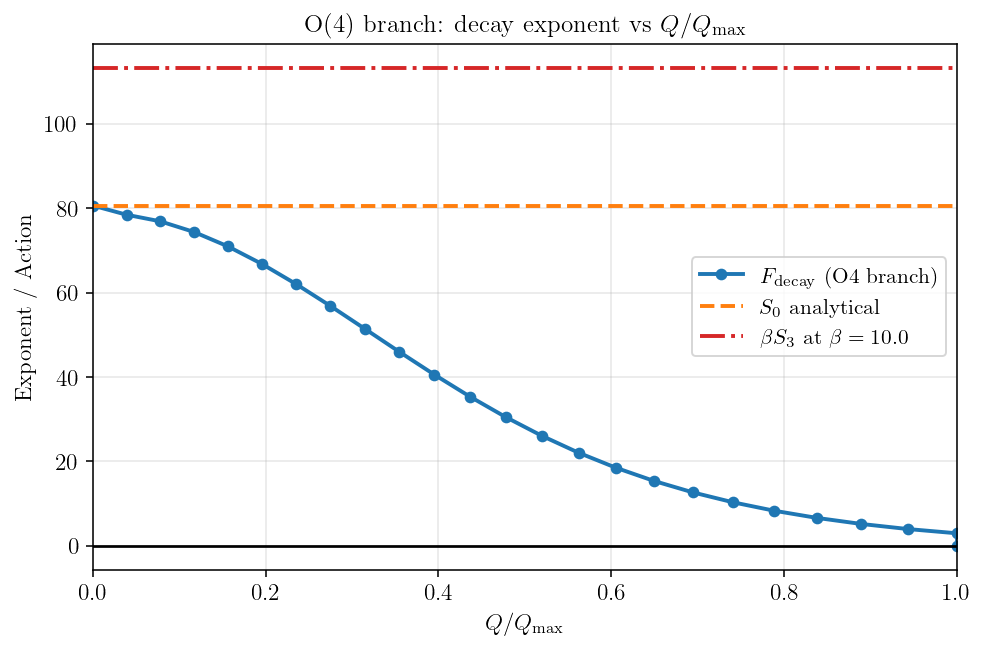

S0 analytical = 8.05904656e+01
S3 reference  = 1.13212579e+01
beta*S3       = 1.13212579e+02
rho_Q,max     = 1.28093228e+00
Added blue-curve anchors: (Q/Q_max, F) = (0, S0) and (1, 0).


In [68]:
from scipy.special import spence
from Bubble_finder.bounce_1d import solve_bounce

def S0_analytical_plot(phi0):
    """S0 analytical constant used as reference line."""
    term = (phi0 - 1.0) / (phi0 - 2.0)
    Li2_val = spence(1.0 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1.0 + Li2_val)

valid_o4_omega = [r for r in omega_scan_o4_results if r.get("status") == "ok"]
if len(valid_o4_omega) == 0:
    print("No successful O(4) omega-scan points to plot.")
else:
    omega_vals = np.array([r["omega"] for r in valid_o4_omega], dtype=float)
    F_decay_vals = np.array([r["F_decay"] for r in valid_o4_omega], dtype=float)
    rho_Q_vals = np.array([r["rho_Q"] for r in valid_o4_omega], dtype=float)

    # Normalize charge density by the max value reached in the scan
    rho_Q_max_scan = float(np.max(rho_Q_vals)) if len(rho_Q_vals) > 0 else 1.0
    rho_Q_norm = rho_Q_vals / max(rho_Q_max_scan, 1e-30)

    # S0 and S3 references (as in Final_Bubble_2D style)
    S0_const = float(S0_analytical_plot(MODEL.phi0))

    r_1d_w0, phi_1d_w0, _, _, _ = solve_bounce(
        MODEL.phi0,
        MODEL.v1,
        MODEL.v2,
        0.0,
        d=3,
        r0=1e-10,
        rmax=CFG_2D["Lr"],
        max_iter=180,
        verbose=False,
    )
    r_1d_w0 = np.asarray(r_1d_w0, dtype=float)
    phi_1d_w0 = np.asarray(phi_1d_w0, dtype=float)

    rho_false_w0, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, 0.0, verbose=False)
    V_false_w0 = float(np.asarray(U(np.array([float(rho_false_w0)], dtype=float))).flat[0])
    dphi_dr_w0 = np.gradient(phi_1d_w0, r_1d_w0)
    V_at_phi_w0 = np.asarray(U(phi_1d_w0), dtype=float).flatten()
    integrand_S3 = r_1d_w0**2 * (0.5 * dphi_dr_w0**2 + V_at_phi_w0 - V_false_w0)
    S3_ref = float(4.0 * np.pi * np.trapz(integrand_S3, r_1d_w0))
    beta_ref = float(CFG_2D["beta"])

    # Add requested anchor points to the blue curve before plotting:
    # (0, S0) and (omega_max, 0) -> in Q/Qmax coordinates this is (0, S0) and (1, 0)
    x_q = np.concatenate([np.array([0.0]), rho_Q_norm, np.array([1.0])])
    y_f = np.concatenate([np.array([S0_const]), F_decay_vals, np.array([0.0])])

    ord_q = np.argsort(x_q)
    x_q_plot = x_q[ord_q]
    y_f_plot = y_f[ord_q]

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.plot(x_q_plot, y_f_plot, "o-", lw=2, ms=5, label=r"$F_{\mathrm{decay}}$ (O4 branch)")
    ax.axhline(S0_const, color="C1", ls="--", lw=2, label=r"$S_0$ analytical")
    ax.axhline(beta_ref * S3_ref, color="C3", ls="-.", lw=2, label=rf"$\beta S_3$ at $\beta={beta_ref:.1f}$")
    ax.axhline(0, color='k', ls="-", lw=1.4)
    ax.set_xlabel(r"$Q/Q_{\max}$")
    ax.set_ylabel(r"Exponent / Action")
    ax.set_xlim(0,1)
    ax.set_title(r"O(4) branch: decay exponent vs $Q/Q_{\max}$")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    if CFG["save_figures"]:
        fig.savefig(CFG["figures_dir"] / "o4_omega_scan_decay_exponent_vs_Q_only.pdf", bbox_inches="tight")
    plt.show()

    print(f"S0 analytical = {S0_const:.8e}")
    print(f"S3 reference  = {S3_ref:.8e}")
    print(f"beta*S3       = {(beta_ref*S3_ref):.8e}")
    print(f"rho_Q,max     = {rho_Q_max_scan:.8e}")
    print("Added blue-curve anchors: (Q/Q_max, F) = (0, S0) and (1, 0).")


## 16. Fancy Plots: Symmetry-Extended O(4) Map

Using the already converged O(4)-seed solution at the reference frequency $\omega_{\mathrm{ref}}$, we build a symmetry-extended visualization over the full rectangle:

$$
(r,\tau)\in[-r_{\max},r_{\max}]\times[-\beta/2,\beta/2].
$$

Construction used for plotting:

- even reflection in $r$ (copy from $r\ge 0$ to $r\le 0$),
- even reflection in $\tau$ (copy from $\tau\le 0$ to $\tau\ge 0$).

This gives a full-plane map of $\rho(r,\tau)$ from the half-domain solver output.


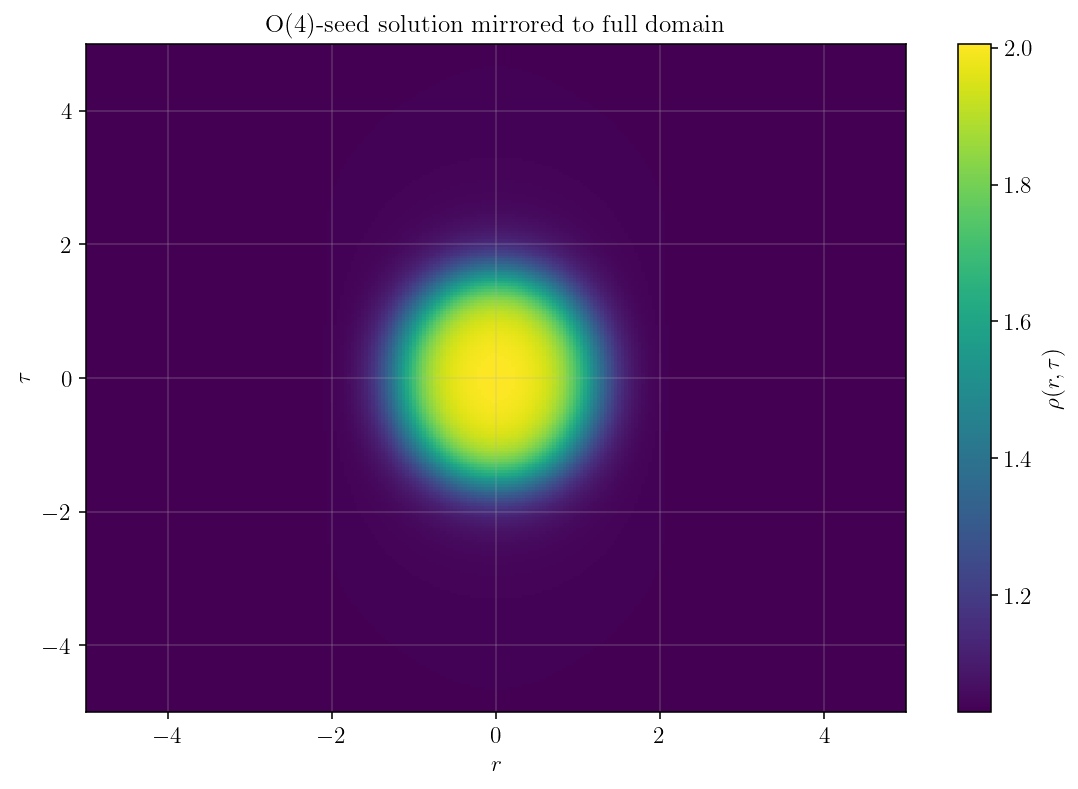

In [111]:
# Symmetry-extended O(4) map on full (r, tau) domain
rho_o4_ref = np.asarray(solver_o4.rho_map(sol_o4.y, sol_o4.ybar), dtype=float)  # (Nr, Ntau_half)
r_half = np.asarray(solver_o4.grid.r, dtype=float).flatten()
tau_half = np.asarray(solver_o4.grid.tau, dtype=float).flatten()

# Build |tau|-ordered half data to apply even reflection in tau
tau_abs = np.abs(tau_half)
ord_tau = np.argsort(tau_abs)
tau_abs_sorted = tau_abs[ord_tau]
rho_tau_sorted = rho_o4_ref[:, ord_tau]

# Full tau in [-beta/2, beta/2], avoiding duplicate tau=0
tau_full = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])
rho_full_tau = np.concatenate([rho_tau_sorted[:, ::-1], rho_tau_sorted[:, 1:]], axis=1)

# Even reflection in r: r in [-Lr, Lr], avoiding duplicate r=0
r_full = np.concatenate([-r_half[::-1], r_half[1:]])
rho_full = np.concatenate([rho_full_tau[::-1, :], rho_full_tau[1:, :]], axis=0)

R_full, T_full = np.meshgrid(r_full, tau_full, indexing="ij")

fig, ax = plt.subplots(figsize=(8.2, 5.8))
pcm = ax.pcolormesh(R_full, T_full, rho_full, shading="auto", cmap="viridis")
cb = fig.colorbar(pcm, ax=ax)
cb.set_label(r"$\rho(r,\tau)$")

ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"O(4)-seed solution mirrored to full domain")
ax.set_xlim(-float(r_half.max()), float(r_half.max()))
ax.set_ylim(-0.5 * float(solver_o4.settings.beta), 0.5 * float(solver_o4.settings.beta))

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "o4_fancy_full_symmetry_map.pdf", bbox_inches="tight")
plt.show()


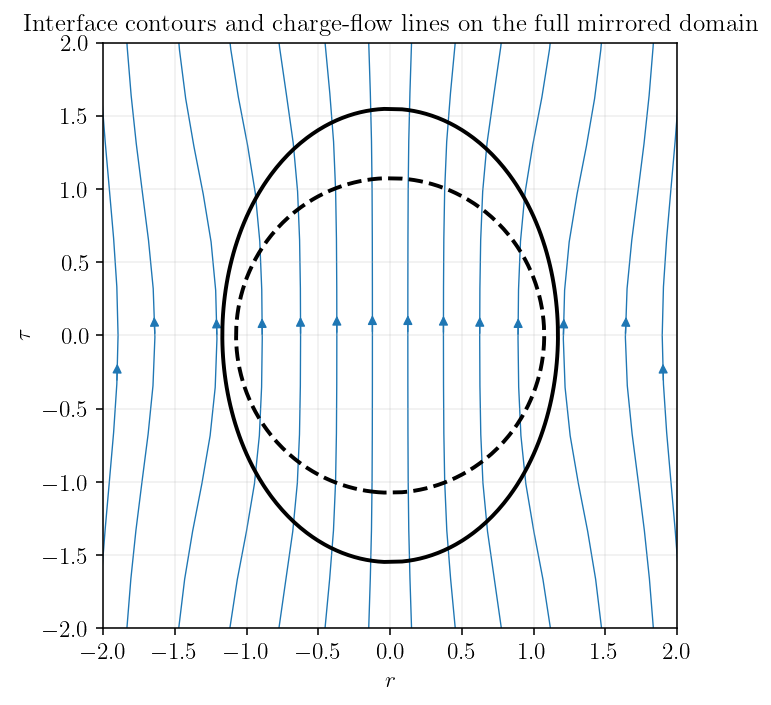

rho_out(ref false vacuum) = 1.03120180e+00
level_sol  = (rho_in_sol + rho_out)/2  = 1.51829048e+00
level_seed = (rho_in_seed + rho_out)/2 = 1.52183641e+00
|j|_max (solution) = 2.80525464e+00


In [117]:
# Interface contour comparison: final O(4) solution vs direct O(4) seed
# Charge-flow lines are plotted from the current components
#   j_tau = Re(phibar * d_tau phi - phi * d_tau phibar)
#   j_r   = Re(phibar * d_r   phi - phi * d_r   phibar)

# --- final O(4) solution map (reference omega) ---
rho_sol_half = np.asarray(solver_o4.rho_map(sol_o4.y, sol_o4.ybar), dtype=float)
r_half = np.asarray(solver_o4.grid.r, dtype=float).flatten()
tau_half = np.asarray(solver_o4.grid.tau, dtype=float).flatten()

# --- direct O(4) seed map rebuilt in physical rho units ---
y_seed_o4, ybar_seed_o4 = solver_o4_seed.unpack(np.asarray(x0_o4_seed, dtype=float))
rho_seed_half = np.asarray(solver_o4_seed.rho_map(y_seed_o4, ybar_seed_o4), dtype=float)

# ============================================================
# Build charge-current components (final O(4) solution only)
# ============================================================
y_sol = np.asarray(sol_o4.y)
ybar_sol = np.asarray(sol_o4.ybar)

phi_sol, phibar_sol = solver_o4.phi(y_sol, ybar_sol)

omega_sol = float(solver_o4.omega)
rho0_sol = float(solver_o4.rho0)
dtau_sol = float(getattr(solver_o4, "dt", getattr(solver_o4.grid, "dtau", None)))

Nr, Nt = y_sol.shape

# --- tau component of the current ---
j_tau_half = np.zeros_like(rho_sol_half, dtype=float)

inv_r = np.zeros_like(r_half, dtype=float)
inv_r[r_half != 0.0] = 1.0 / r_half[r_half != 0.0]

for i_tau in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver_o4._tau_neighbors(y_sol, ybar_sol, i_tau)

    if len(tau_half) >= 2 and (tau_half[1] > tau_half[0]):
        y_t = (y_ip1 - y_im1) / (2.0 * dtau_sol)
        yb_t = (yb_ip1 - yb_im1) / (2.0 * dtau_sol)
    else:
        y_t = (y_im1 - y_ip1) / (2.0 * dtau_sol)
        yb_t = (yb_im1 - yb_ip1) / (2.0 * dtau_sol)

    y_tot = y_sol[:, i_tau] + r_half * rho0_sol
    yb_tot = ybar_sol[:, i_tau] + r_half * rho0_sol

    exp_p = np.exp(+omega_sol * tau_half[i_tau]) * inv_r
    exp_m = np.exp(-omega_sol * tau_half[i_tau]) * inv_r

    phi_tau = exp_p * (y_t + omega_sol * y_tot)
    phibar_tau = exp_m * (yb_t - omega_sol * yb_tot)

    j_tau_half[:, i_tau] = (phibar_sol[:, i_tau] * phi_tau - phi_sol[:, i_tau] * phibar_tau).real

# --- radial component of the current ---
j_r_half = np.zeros_like(rho_sol_half, dtype=float)

for i_tau in range(Nt):
    dphi_dr = np.gradient(phi_sol[:, i_tau], r_half, edge_order=2)
    dphibar_dr = np.gradient(phibar_sol[:, i_tau], r_half, edge_order=2)

    # Regularity at r = 0
    dphi_dr[0] = 0.0
    dphibar_dr[0] = 0.0

    j_r_half[:, i_tau] = (phibar_sol[:, i_tau] * dphi_dr - phi_sol[:, i_tau] * dphibar_dr).real

# ============================================================
# Helpers to mirror scalar maps and current components
# ============================================================
def _mirror_full_domain_scalar(r_vec, tau_vec, field_half):
    tau_abs = np.abs(np.asarray(tau_vec, dtype=float).flatten())
    ord_tau = np.argsort(tau_abs)
    tau_abs_sorted = tau_abs[ord_tau]
    field_tau_sorted = np.asarray(field_half, dtype=float)[:, ord_tau]

    tau_full_loc = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])
    field_full_tau_loc = np.concatenate([field_tau_sorted[:, ::-1], field_tau_sorted[:, 1:]], axis=1)

    r_loc = np.asarray(r_vec, dtype=float).flatten()
    r_full_loc = np.concatenate([-r_loc[::-1], r_loc[1:]])
    field_full_loc = np.concatenate([field_full_tau_loc[::-1, :], field_full_tau_loc[1:, :]], axis=0)

    return r_full_loc, tau_full_loc, field_full_loc


def _mirror_full_domain_current(r_vec, tau_vec, jr_half, jtau_half):
    """
    Mirror a current field from the half-domain r>=0 onto the full domain.

    Parities used:
      - under r -> -r:     j_r is odd,  j_tau is even
      - under tau -> -tau: j_r is even, j_tau is even

    These are the natural choices for the symmetric bounce visualization.
    """
    tau_abs = np.abs(np.asarray(tau_vec, dtype=float).flatten())
    ord_tau = np.argsort(tau_abs)
    tau_abs_sorted = tau_abs[ord_tau]

    jr_tau_sorted = np.asarray(jr_half, dtype=float)[:, ord_tau]
    jtau_tau_sorted = np.asarray(jtau_half, dtype=float)[:, ord_tau]

    tau_full_loc = np.concatenate([-tau_abs_sorted[::-1], tau_abs_sorted[1:]])

    # even under tau reflection
    jr_full_tau_loc = np.concatenate([jr_tau_sorted[:, ::-1], -jr_tau_sorted[:, 1:]], axis=1)
    jtau_full_tau_loc = np.concatenate([jtau_tau_sorted[:, ::-1], jtau_tau_sorted[:, 1:]], axis=1)
    #jr_full_tau_loc   = np.concatenate([ jr_tau_sorted[:, ::-1], jr_tau_sorted[:, 1:]], axis=1)
    #jtau_full_tau_loc = np.concatenate([-jtau_tau_sorted[:, ::-1], jtau_tau_sorted[:, 1:]], axis=1)

    r_loc = np.asarray(r_vec, dtype=float).flatten()
    r_full_loc = np.concatenate([-r_loc[::-1], r_loc[1:]])

    # j_r odd under r reflection, j_tau even under r reflection
    jr_full_loc = np.concatenate([-jr_full_tau_loc[::-1, :], jr_full_tau_loc[1:, :]], axis=0)
    jtau_full_loc = np.concatenate([jtau_full_tau_loc[::-1, :], jtau_full_tau_loc[1:, :]], axis=0)

    return r_full_loc, tau_full_loc, jr_full_loc, jtau_full_loc


# --- mirrored full-domain maps ---
r_full_sol, tau_full_sol, rho_full_sol = _mirror_full_domain_scalar(r_half, tau_half, rho_sol_half)
r_full_seed, tau_full_seed, rho_full_seed = _mirror_full_domain_scalar(r_half, tau_half, rho_seed_half)
r_full_j, tau_full_j, jr_full_sol, jtau_full_sol = _mirror_full_domain_current(r_half, tau_half, j_r_half, j_tau_half)

# ============================================================
# Mid-level thresholds for the interface
# ============================================================
rho_out_ref, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF, verbose=False)
rho_out_ref = float(rho_out_ref)

rho_in_sol = float(np.max(rho_full_sol))
rho_in_seed = float(np.max(rho_full_seed))
level_sol = 0.5 * (rho_in_sol + rho_out_ref)
level_seed = 0.5 * (rho_in_seed + rho_out_ref)

# ============================================================
# Streamplot requires equally spaced x/y grids:
# interpolate current field to a uniform (r, tau) mesh.
# ============================================================
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

# Upsample to a finer uniform mesh for smoother streamlines.
upsample_factor = 4
nr_uni = max(240, int(upsample_factor * len(r_full_j)))
nt_uni = max(240, int(upsample_factor * len(tau_full_j)))

r_uni = np.linspace(float(r_full_j.min()), float(r_full_j.max()), nr_uni)
tau_uni = np.linspace(float(tau_full_j.min()), float(tau_full_j.max()), nt_uni)

# Cubic interpolation on (r, tau) and then a light Gaussian smoothing.
jr_spline = RectBivariateSpline(r_full_j, tau_full_j, jr_full_sol, kx=3, ky=3, s=0.0)
jtau_spline = RectBivariateSpline(r_full_j, tau_full_j, jtau_full_sol, kx=3, ky=3, s=0.0)

# RectBivariateSpline returns shape (Nr, Nt); streamplot expects (Nt, Nr).
jr_uni = jr_spline(r_uni, tau_uni).T
jtau_uni = jtau_spline(r_uni, tau_uni).T

sigma_smooth = 0.8
jr_uni = gaussian_filter(jr_uni, sigma=sigma_smooth, mode="nearest")
jtau_uni = gaussian_filter(jtau_uni, sigma=sigma_smooth, mode="nearest")

jmag_uni = np.sqrt(jr_uni**2 + jtau_uni**2)
jmag_max = float(np.max(jmag_uni)) if jmag_uni.size else 0.0

# Avoid huge linewidth contrast while keeping visible fine structures.
if jmag_max > 0.0:
    lw_stream = 0.55 + 1.35 * (jmag_uni / jmag_max) ** 0.7
else:
    lw_stream = 0.9

# ============================================================
# Plot: interfaces + charge-flow lines
# ============================================================
fig, ax = plt.subplots(figsize=(5.2, 5.2))

# Final solution interface
ax.contour(
    r_full_sol,
    tau_full_sol,
    rho_full_sol.T,
    levels=[level_sol],
    colors="k",
    linewidths=2.0,
    linestyles="-",
)

# Direct O(4) seed interface
ax.contour(
    r_full_seed,
    tau_full_seed,
    rho_full_seed.T,
    levels=[level_seed],
    colors="k",
    linewidths=2.0,
    linestyles="--",
)

# Charge-flow lines (streamlines of the current field)
if jmag_max > 0.0:
    ax.streamplot(
        r_uni,
        tau_uni,
        jr_uni,
        jtau_uni,
        color="C0",
        density=(1.0, 0.5),
        linewidth=0.7,
        arrowsize=1,   # no arrows, only flow lines
        minlength=0.01,
        maxlength=2.0,
        integration_direction="both",
        broken_streamlines=False,
        zorder=1,
    )

# Legend handles
ax.plot([], [], "k-", lw=2.0, label=r"Final O(4) solution: $\rho=(\rho_{\mathrm{in}}+\rho_{\mathrm{out}})/2$")
ax.plot([], [], "k--", lw=2.0, label=r"Direct O(4) seed: $\rho=(\rho_{\mathrm{in}}+\rho_{\mathrm{out}})/2$")
ax.plot([], [], color="C0", lw=1.2, label=r"Charge-flow lines of the final solution")

ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Interface contours and charge-flow lines on the full mirrored domain")
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
#ax.legend(loc="best")
ax.grid(True, alpha=0.2)

fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(
        CFG["figures_dir"] / "o4_interface_and_charge_flow_solution_vs_seed.pdf",
        bbox_inches="tight"
    )
plt.show()

print(f"rho_out(ref false vacuum) = {rho_out_ref:.8e}")
print(f"level_sol  = (rho_in_sol + rho_out)/2  = {level_sol:.8e}")
print(f"level_seed = (rho_in_seed + rho_out)/2 = {level_seed:.8e}")
print(f"|j|_max (solution) = {jmag_max:.8e}")

## 17. Final Sanity Check and Cleanup Candidates

### What was computed

- $V(\phi)$ and $\Omega(\phi)$ with vacuum identification at reference $\omega$,
- 1D bounces for $O(1), O(3), O(4)$ at fixed $\omega$ and at $\omega=0$,
- 1D observables and a clean $\omega$ scan for $O(3), O(4)$,
- centralized 2D setup with default grid and solver parameters,
- unified seed framework (`O4_seed`, `O3_static_seed`, `O1_tau_seed`, `homogeneous_seed`),
- full 2D solve from each seed with $\eta_0$-matching,
- 2D-vs-1D slice comparisons,
- static-energy diagnostic and extended energy decompositions vs $\tau$,
- descending-$\beta$ continuation scans for O(4), O(3), and O(1) branches with per-step $\eta_0$ charge matching and stored $E/E_{\mathrm{ref}}$ trajectories,
- O(4)-branch $\omega$ continuation with per-step $\eta_0$ matching and decay-exponent tracking vs $\omega$ and $Q/Q_{\max}$,
- symmetry-extended full-domain O(4) map in $(r,\tau)\in[-r_{\max},r_{\max}]\times[-\beta/2,\beta/2]$ for visualization.

### Files created/modified for this clean workflow

- `BubbleX/Bubble_finder/clean_analysis_helpers.py` (new helper backend)
- `BubbleX/Bubble_finder/notebooks/Bubble_Analysis_Clean.ipynb` (new main notebook)

### Explicit cleanup candidates to review later

The following items look potentially redundant/obsolete/duplicated in the current codebase and should be reviewed before deletion:

1. Repeated plotting and diagnostics helper blocks scattered in old notebooks (`Final_Bubble_2D.ipynb`, `SeedSearch_NewAnsatz.ipynb`, `bubble_nucleation_explanation.ipynb`).
2. Legacy/duplicate seed-building paths in notebooks that overlap with centralized `build_seed` logic.
3. Mixed usage of energy conventions in old notebook cells (labels named `E` while actually plotting $F_\omega$ or Euclidean $H_E$).
4. Duplicate ad hoc $\eta_0$ scan loops in notebook cells when `scan_eta0_to_match_Q` already centralizes this logic.
5. Repeated one-off interpolation and profile-comparison snippets that can now be replaced by `clean_analysis_helpers.py` utilities.

### Consistency notes

This notebook intentionally follows backend conventions currently implemented in `potential_bubble.py`, `bounce_1d.py`, `bounce2d.py`, `observables_1d.py`, and `observables_2d.py`. If any convention mismatch is observed during execution, keep backend definitions as source of truth and document discrepancies explicitly in this section.


In [35]:
# Lightweight execution-time checklist for key objects
required_objects = [
    "MODEL",
    "OMEGA_REF",
    "bounces_fixed",
    "scan_summary",
    "CFG_2D",
    "profiles_for_seeds",
    "summary_o4",
    "static_o4",
    "all_seed_results",
    "beta_scan_results",
    "omega_scan_o4_results",
]

missing = [name for name in required_objects if name not in globals()]
if len(missing) == 0:
    print("Sanity checklist: all key analysis objects are present.")
else:
    print("Sanity checklist: missing objects ->", missing)


Sanity checklist: missing objects -> ['scan_summary']
